# Campaign response model: walkthrough

**Goal.** Rank customers by how likely they are to take up the offer when cold-called, so call effort goes where it
converts. **Secondary goal.** Translate the model's classification into expected campaign profit.

Each section below answers one design question. Code lives in `src/campaign_response/`; this notebook
reads the outputs of `make pipeline` (set `RERUN = True` to rebuild them, roughly 15 minutes).

In [1]:
import json

import joblib
import numpy as np
import pandas as pd
from IPython.display import Image, display

from campaign_response.config import load_config
from campaign_response.data import load_raw
from campaign_response.pipeline import step_evaluate, step_figures, step_periods, step_prepare, step_train

RERUN = False
cfg = load_config()
R, F = cfg.reports, cfg.figures
pd.set_option("display.max_columns", 30, "display.width", 160, "display.float_format", "{:,.4f}".format)
show = lambda name, width=820: display(Image(filename=F / name, width=width))
if RERUN:
    for step in (step_prepare, step_train, step_figures, step_evaluate, step_periods):
        step(cfg)

## 0. The data as delivered

In [2]:
raw = load_raw(cfg.raw_file, cfg["data"]["separator"])
print(raw.shape)
raw.dtypes.value_counts()  # client records are not printed; see data/README.md for the dictionary

(35000, 21)


str        10
int64       6
float64     5
Name: count, dtype: int64

In [3]:
pd.read_csv(R / "data_profile.csv")

,column,kind,distinct,nulls,min,p01,median,p99,max,above_p99,sentinel_999,unknown_share,smallest_level_share
0,age,numeric,77,0,17.0000,23.0000,38.0000,71.0000,98.0000,312.0000,0.0000,NaN,NaN
1,call_duration_s,numeric,1488,0,0.0000,11.0000,179.0000,"1,268.0000","4,918.0000",349.0000,0.0000,NaN,NaN
2,call_attempts,numeric,39,0,1.0000,1.0000,2.0000,14.0000,56.0000,346.0000,0.0000,NaN,NaN
3,days_since_prev_campaign,numeric,26,0,0.0000,3.0000,999.0000,999.0000,999.0000,0.0000,"33,711.0000",NaN,NaN
4,prev_campaign_attempts,numeric,8,0,0.0000,0.0000,0.0000,2.0000,7.0000,264.0000,0.0000,NaN,NaN
5,employment_variation_rate,numeric,10,0,-3.4000,-3.4000,1.1000,1.4000,1.4000,0.0000,0.0000,NaN,NaN
6,consumer_price_index,numeric,26,0,92.2010,92.2010,93.7490,94.4650,94.7670,281.0000,0.0000,NaN,NaN
7,consumer_confidence_index,numeric,26,0,-50.8000,-49.5000,-41.8000,-26.9000,-26.9000,0.0000,0.0000,NaN,NaN
8,interbank_rate_3m,numeric,314,0,0.6340,0.6550,4.8570,4.9680,5.0450,163.0000,0.0000,NaN,NaN
9,number_of_employees,numeric,11,0,"4,963.6000","4,963.6000","5,191.0000","5,228.1000","5,228.1000",0.0000,0.0000,NaN,NaN


## 1. Are all input variables relevant?

No. Two kinds of variables are removed:
- **Leaks.** Call duration is only known after the call, according to the data dictionary.
- **Variables with no discriminating power**, measured by Information Value (IV) on the training split. The
  decision log below records every keep or drop.

In [4]:
pd.read_csv(R / "feature_decisions.csv")

,feature,decision,reason
0,last_contact_weekday,drop,IV 0.008 < 0.02
1,has_home_loan,drop,IV 0.001 < 0.02
2,has_personal_loan,drop,IV 0.001 < 0.02
3,interbank_rate_3m,drop,|Spearman| 0.93 with number_of_employees (high...
4,employment_variation_rate,drop,|Spearman| 0.94 with number_of_employees (high...
5,previously_contacted,drop,Cramer's V 1.00 with prev_contact_recency (hig...
6,number_of_employees,keep,IV 1.114 (suspicious)
7,consumer_confidence_index,keep,IV 0.740 (suspicious)
8,prev_contact_recency,keep,IV 0.548 (suspicious)
9,previous_outcome,keep,IV 0.543 (suspicious)


## 2. What does the data look like? Outliers and corrections

The table below lists each audit step and how many rows or cells it touched. Call attempts has a long tail
(capped at the training 99th percentile inside the model); age extremes (up to 98) are plausible and kept.
`days_since_prev_campaign = 999` is a code for "never contacted", not a number of days, so it is replaced by a
recency band.

In [5]:
pd.read_csv(R / "audit_log.csv")

,step,rows,affected,note
0,raw records,35000,0,"21 columns, 0 nulls"
1,drop exact duplicates,34989,11,identical across all 21 fields
2,decode 999 sentinel,34989,33700,days_since_prev_campaign = 999 -> 'never' rece...
3,check sentinel vs previous outcome,34989,0,'nonexistent' previous outcome must coincide w...
4,keep 'unknown' as a category,34989,10838,unknown is informative (e.g. credit-in-default...
5,leakage: call duration,34989,4,known only after the call; 4 zero-second calls...
6,flag extreme call attempts,34989,346,above the 99th percentile; capped inside the m...
7,final modelling table,34989,23,rows / columns


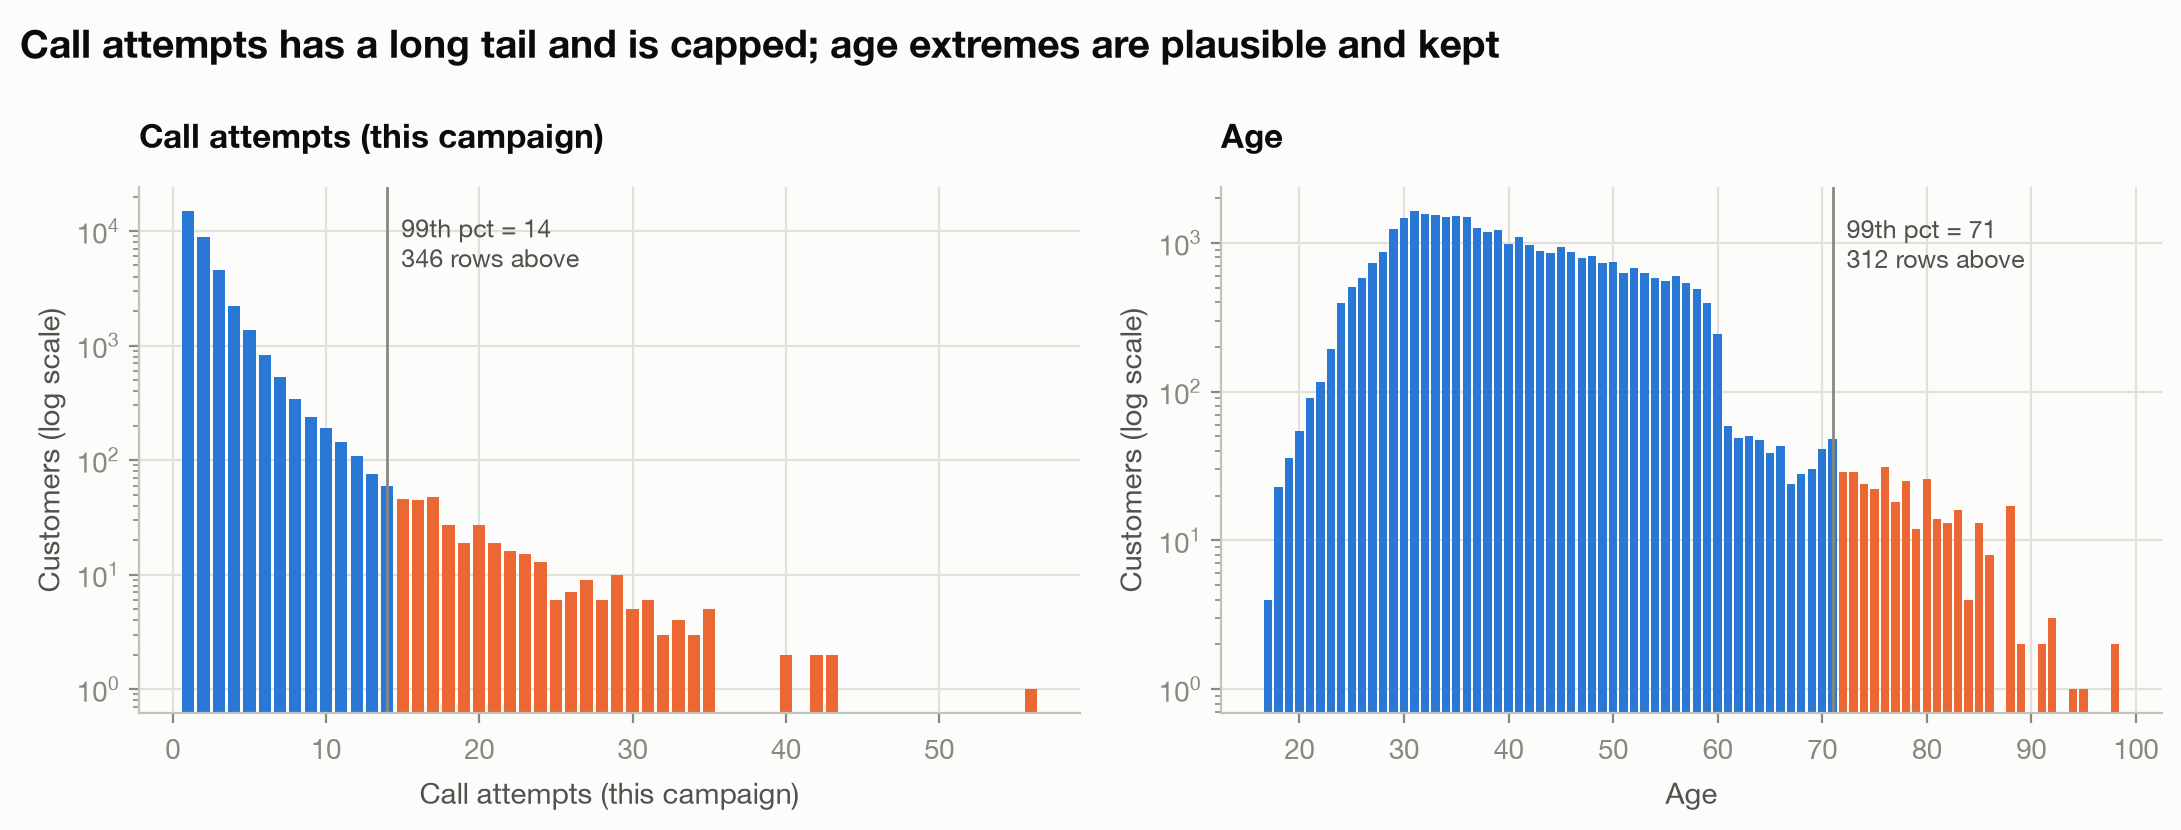

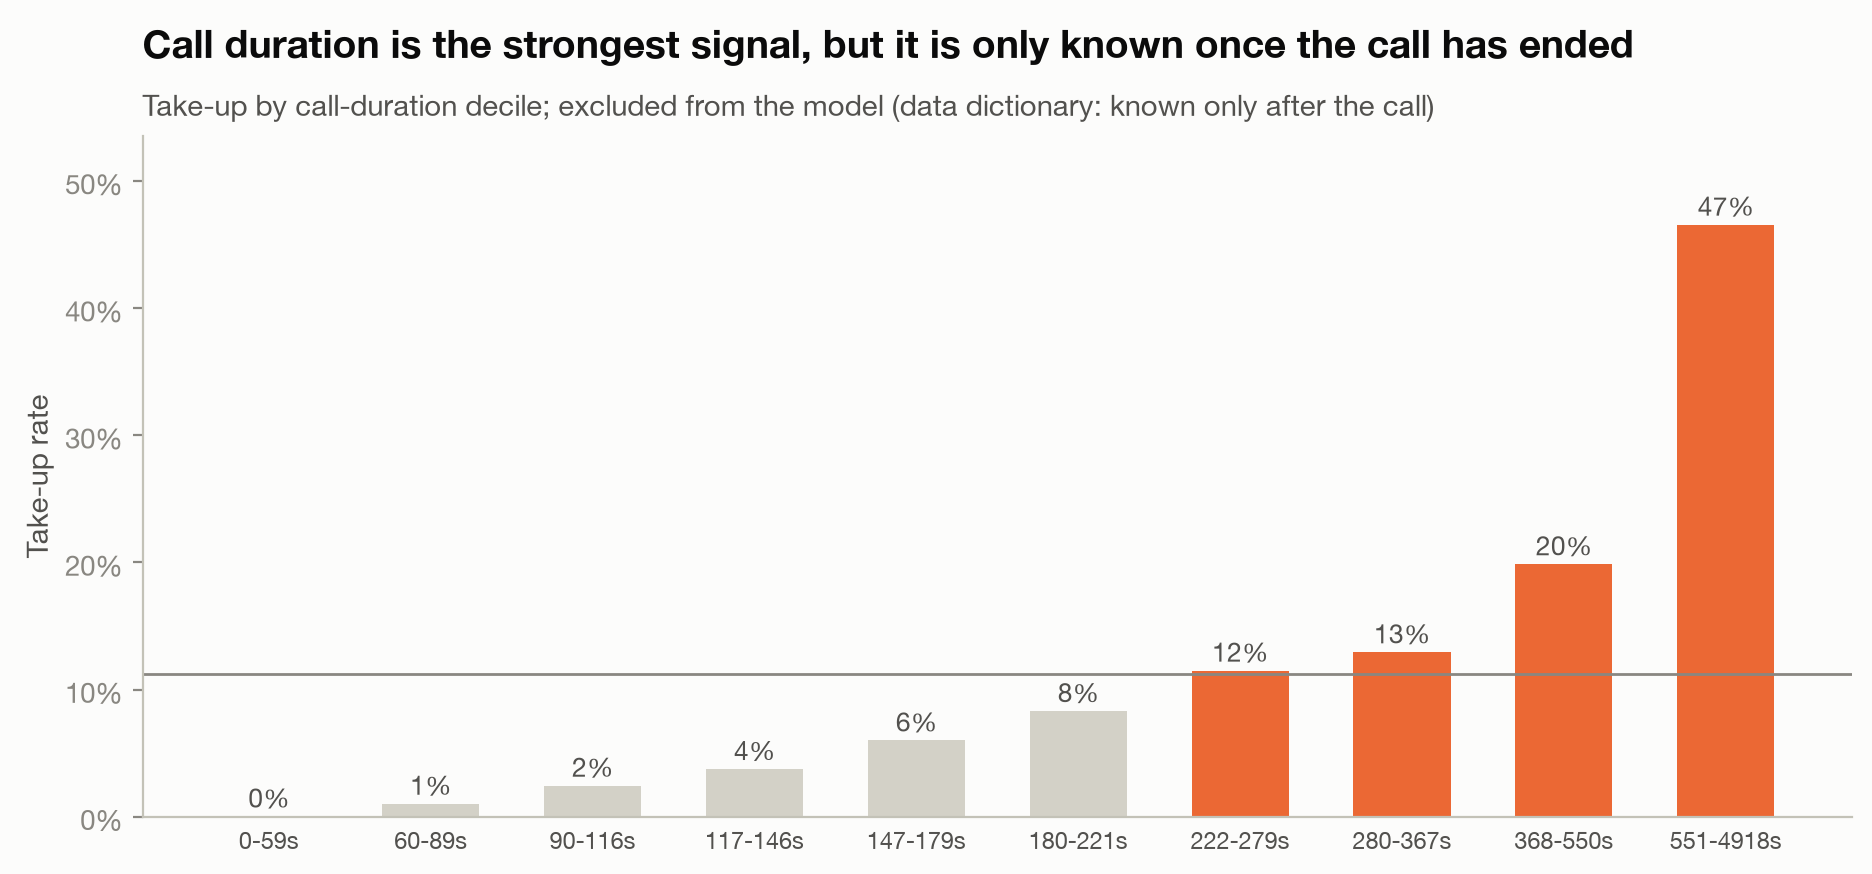

In [6]:
show("02_outliers.png")
show("01_leakage_call_duration.png")

## 3. Is there discriminating power among the variables?

Each candidate variable is scored on the training split with four measures:
- Weight of Evidence (WoE) and Information Value (IV). Rule-of-thumb bands (derived from Siddiqi): below 0.02 not useful, 0.02–0.1
  weak, 0.1–0.3 medium, 0.3–0.5 strong, above 0.5 suspicious.
- Univariate Gini.
- Kolmogorov-Smirnov (KS), for numeric variables.
- Chi-square with Cramér's V, for categorical variables.

The macro indicators score as "suspicious" because they mark campaign periods with very different take-up.
They are known before the call, so they are kept, and their drift risk is noted.

In [7]:
pd.read_csv(R / "information_value.csv")

,feature,iv,strength,bins,gini,ks,chi2_p_value,cramers_v
0,leak_call_duration_s,1.9344,suspicious,10,0.6467,0.4694,NaN,NaN
1,number_of_employees,1.1141,suspicious,5,0.4842,0.4218,NaN,NaN
2,interbank_rate_3m,0.9912,suspicious,10,0.4716,0.4218,NaN,NaN
3,employment_variation_rate,0.7456,suspicious,5,0.4179,0.4218,NaN,NaN
4,consumer_confidence_index,0.7399,suspicious,8,0.0674,0.1874,NaN,NaN
5,prev_contact_recency,0.5479,suspicious,5,0.1919,NaN,0.0000,0.3233
6,previously_contacted,0.5454,suspicious,2,0.1916,0.1916,NaN,NaN
7,previous_outcome,0.5430,suspicious,3,0.2264,NaN,0.0000,0.3189
8,last_contact_month,0.4771,strong,10,0.3127,NaN,0.0000,0.2721
9,consumer_price_index,0.4688,strong,9,0.2070,0.2200,NaN,NaN


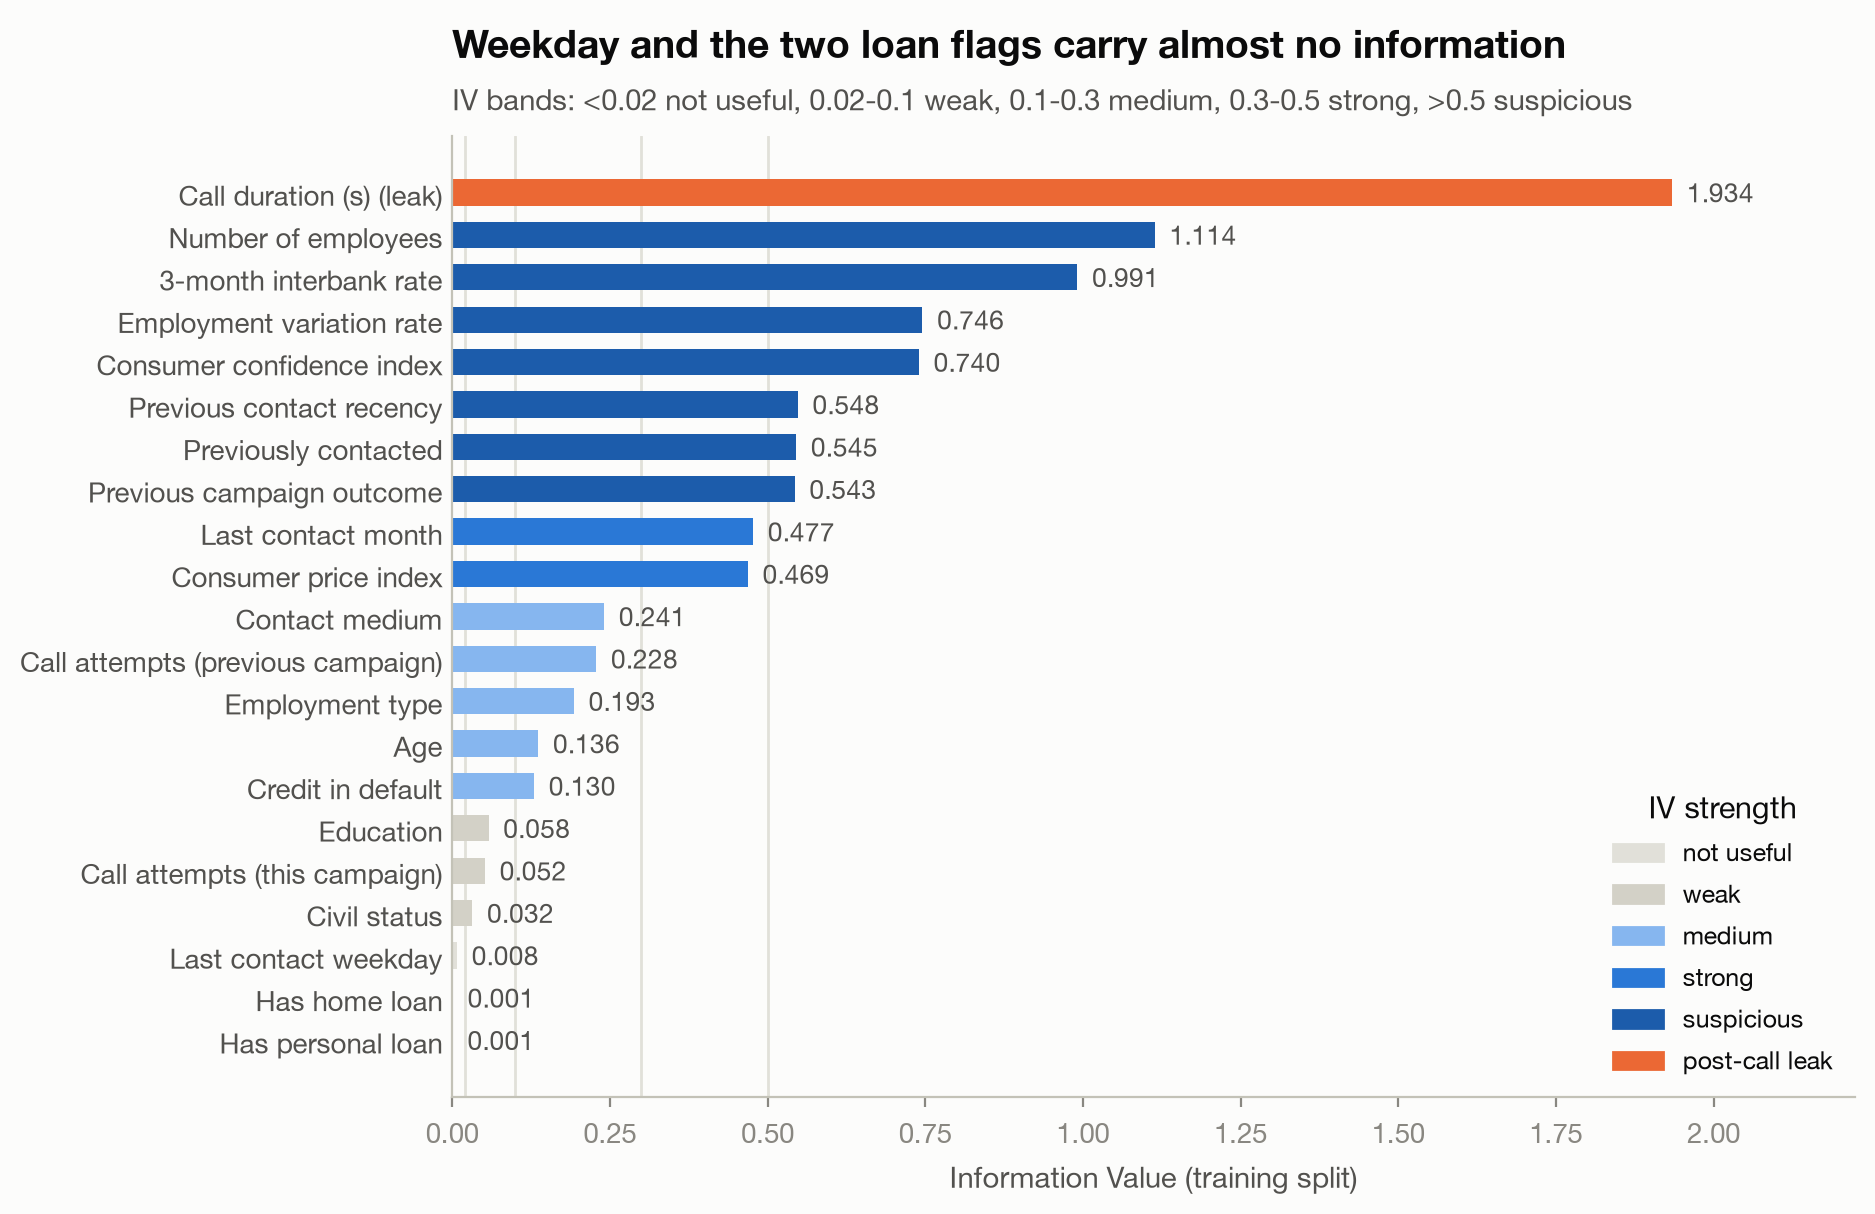

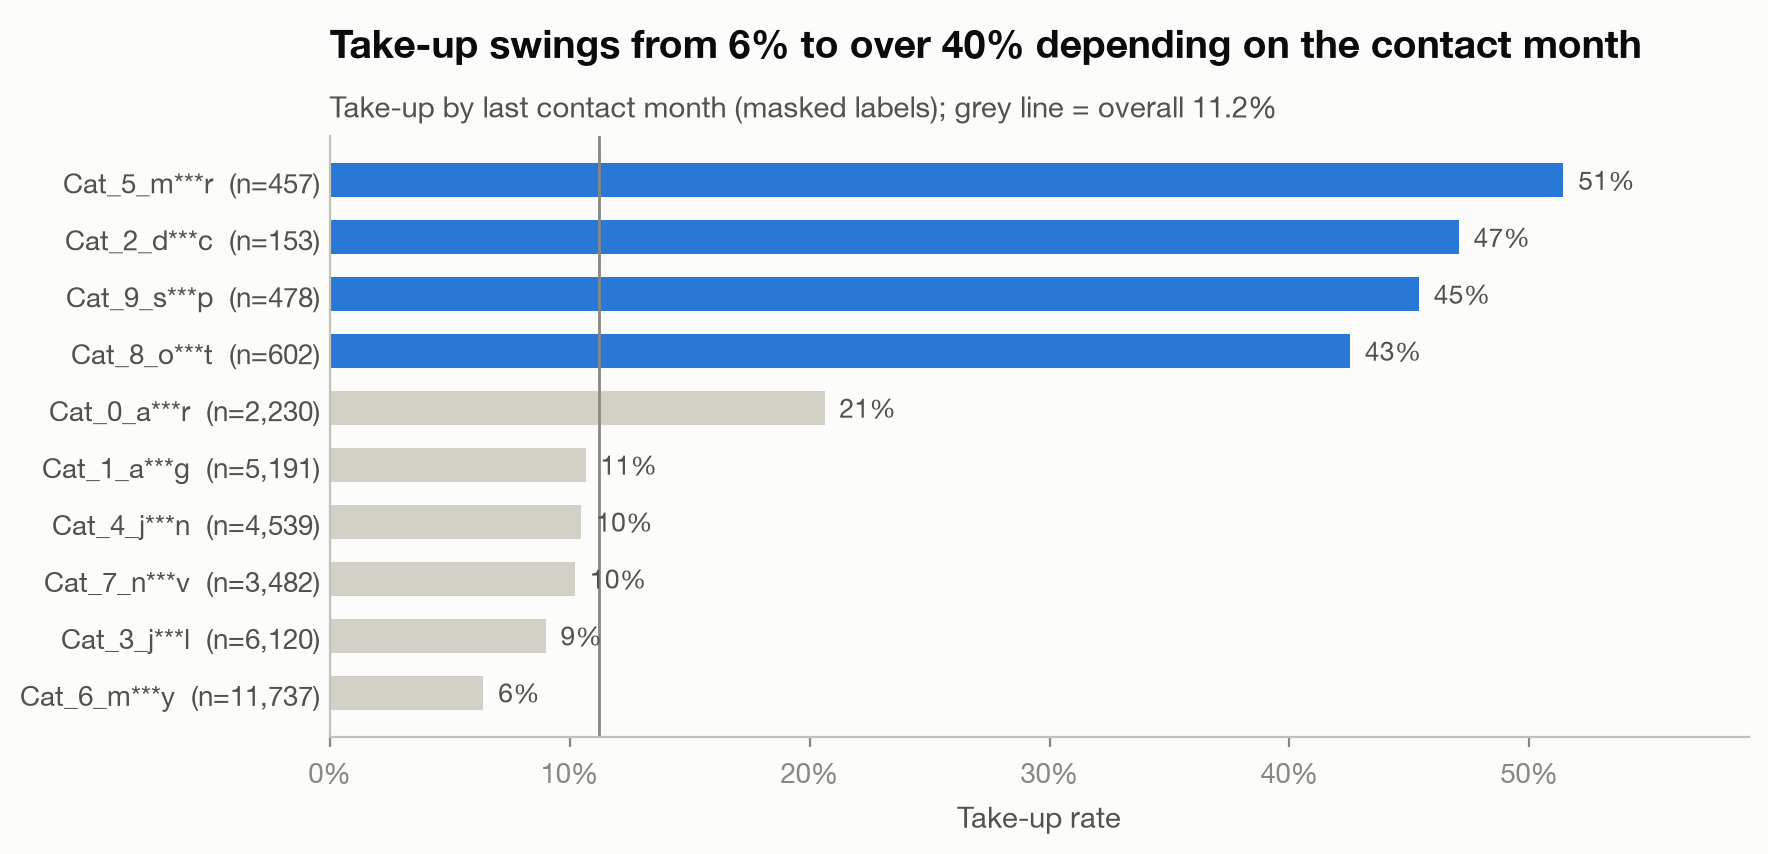

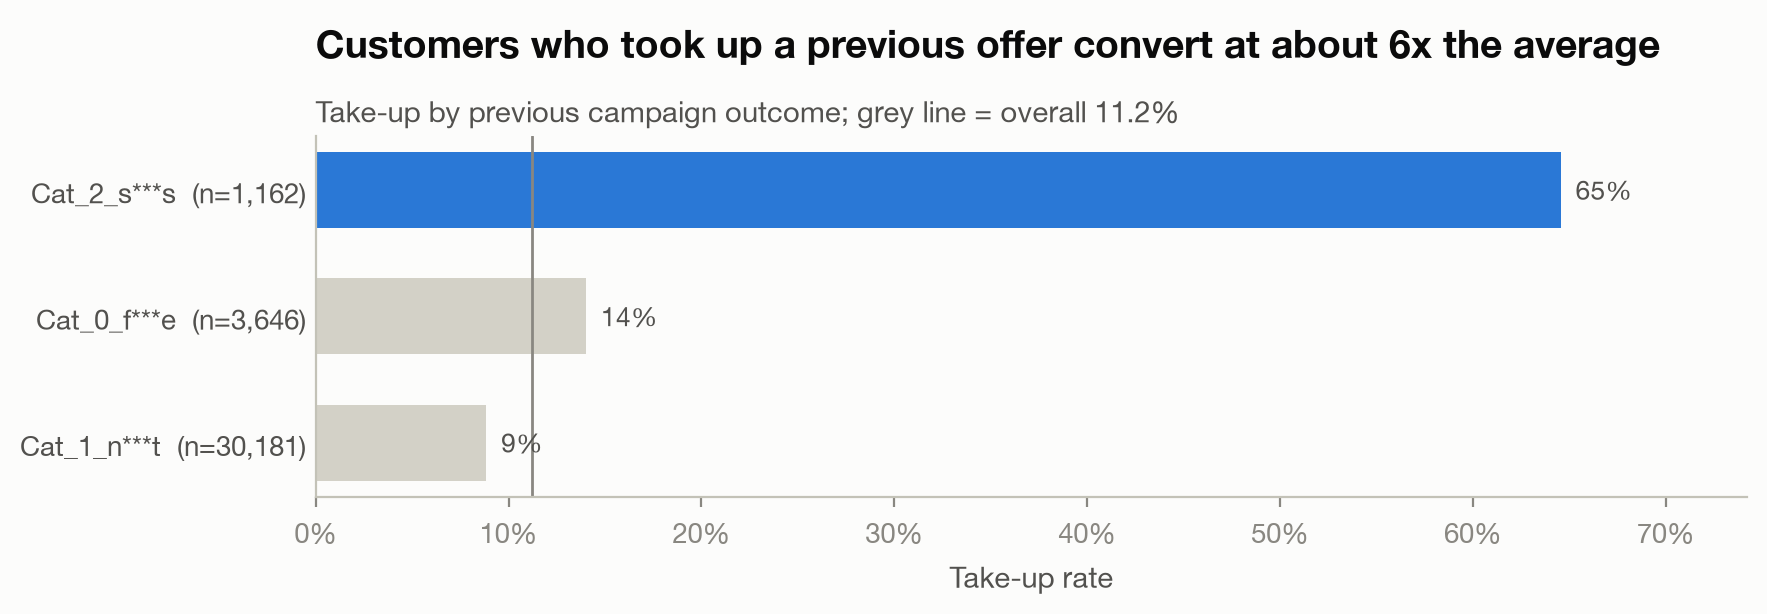

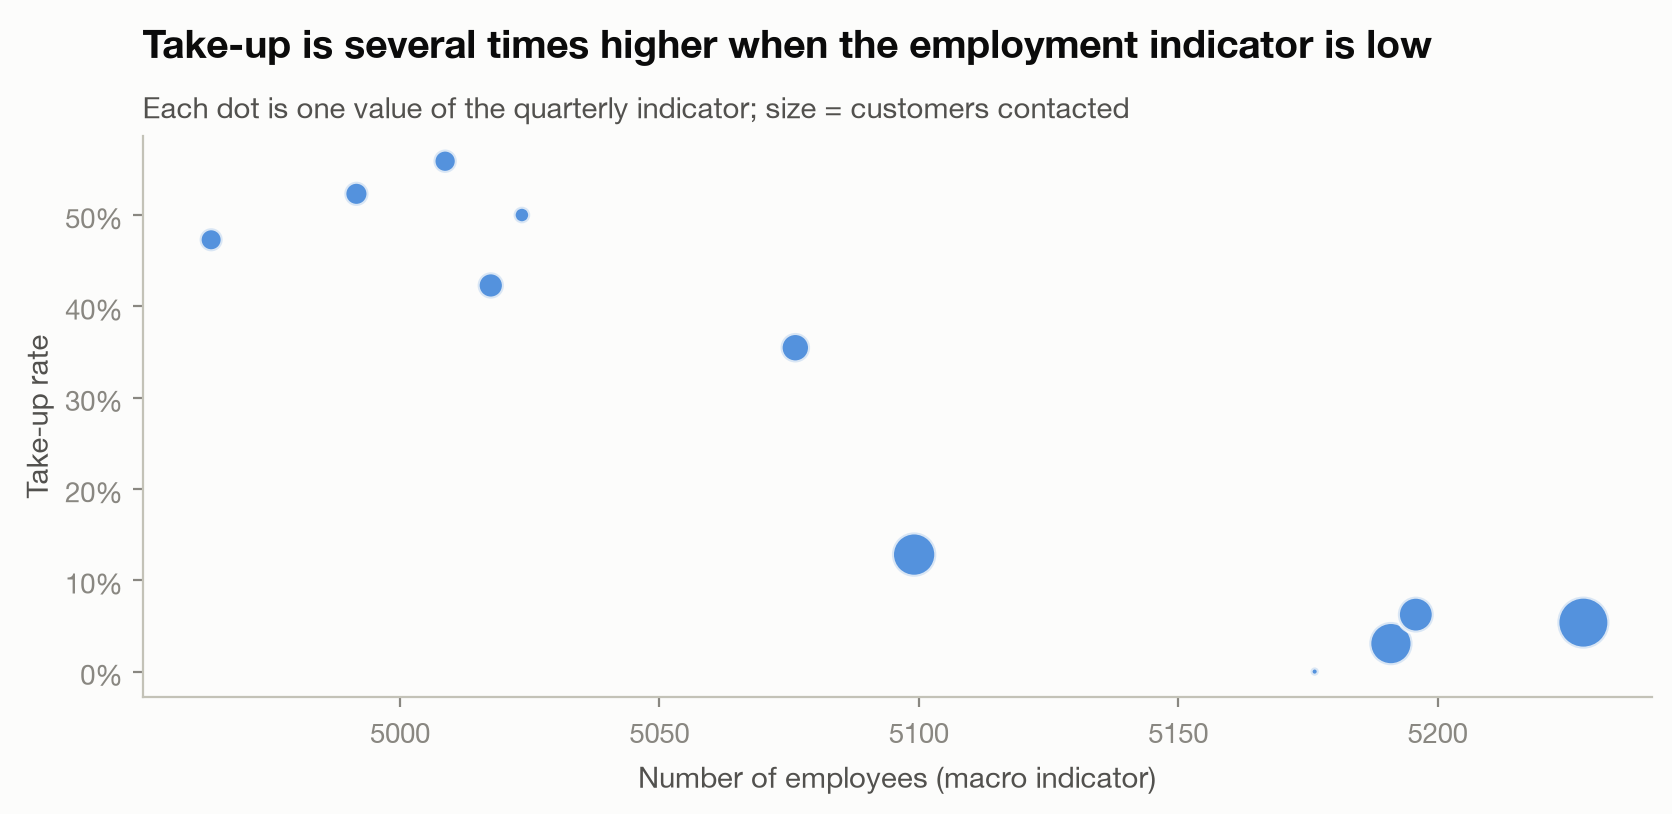

In [8]:
show("03_information_value.png")
show("07_rate_by_month.png")
show("08_rate_by_previous_outcome.png")
show("09_macro_number_of_employees.png")

## 4. How are high correlations controlled?

- **Numeric variables.** Spearman correlation and variance inflation factors (VIF). Within any group with
  |ρ| > 0.85, only the variable with the highest IV is kept.
- **Categorical variables.** Bias-corrected Cramér's V; pairs above 0.8 are treated as redundant.
- **After selection.** Every VIF must be below 10, or the pipeline fails.

In [9]:
display(pd.read_csv(R / "vif_before.csv"))
display(pd.read_csv(R / "vif_after.csv"))

,feature,vif
0,interbank_rate_3m,63.9728
1,employment_variation_rate,32.6605
2,number_of_employees,31.5487
3,consumer_price_index,6.2496
4,consumer_confidence_index,2.6144
5,prev_campaign_attempts,1.3633
6,call_attempts,1.0346
7,age,1.0178


,feature,vif
0,number_of_employees,1.8119
1,consumer_price_index,1.3907
2,prev_campaign_attempts,1.3577
3,consumer_confidence_index,1.0308
4,call_attempts,1.0266
5,age,1.0174


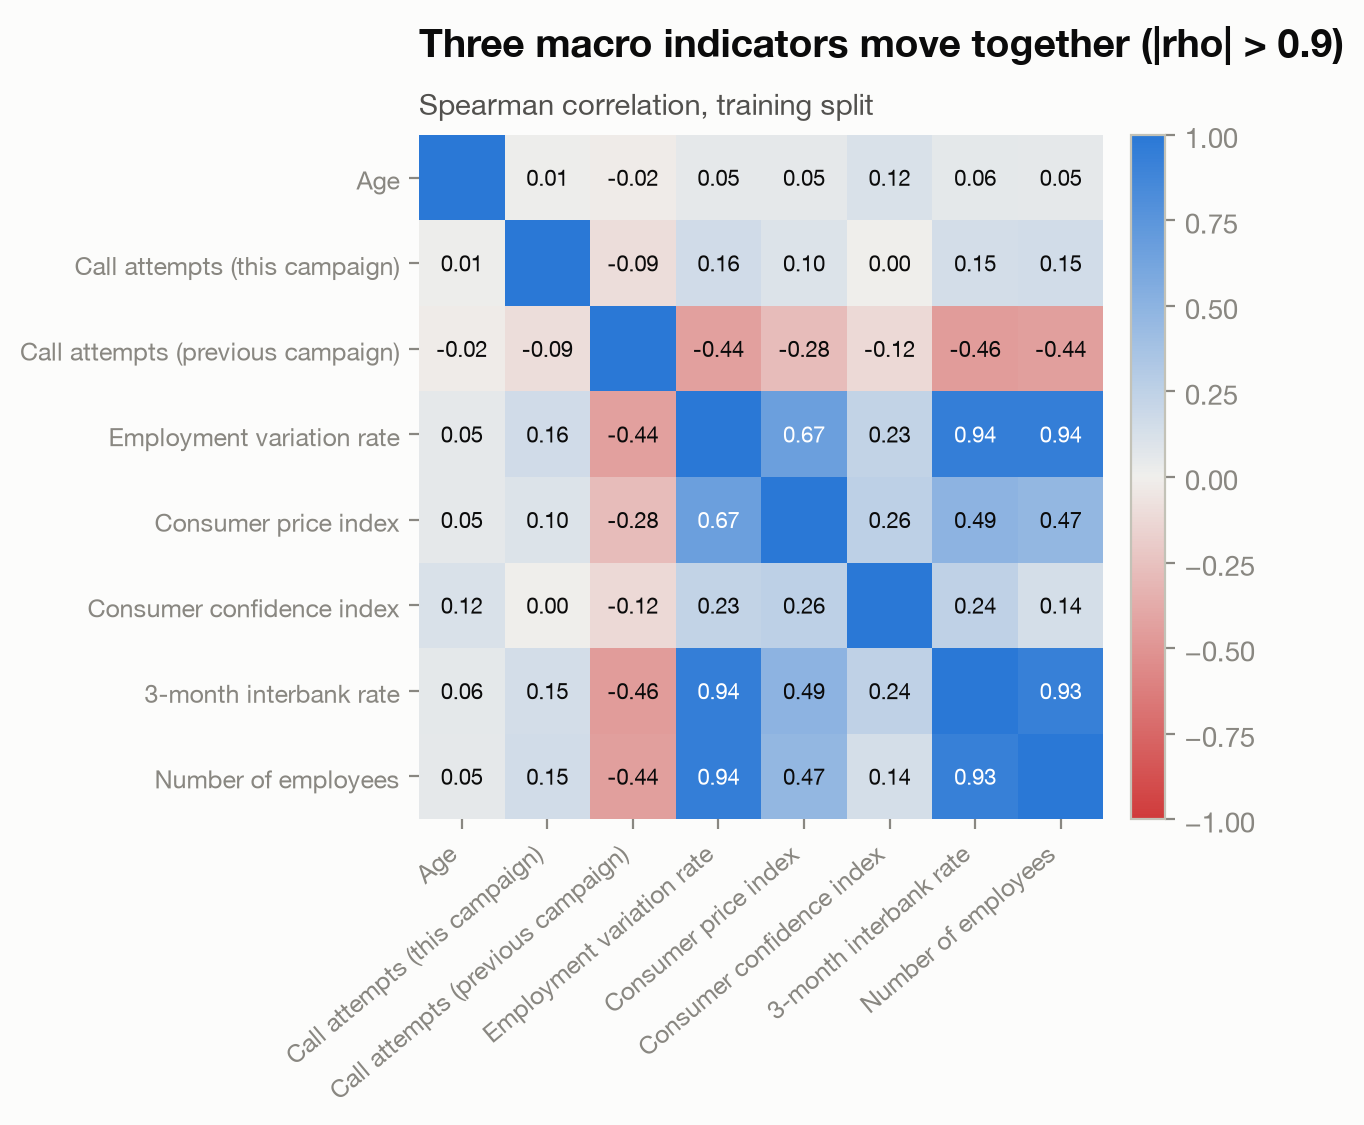

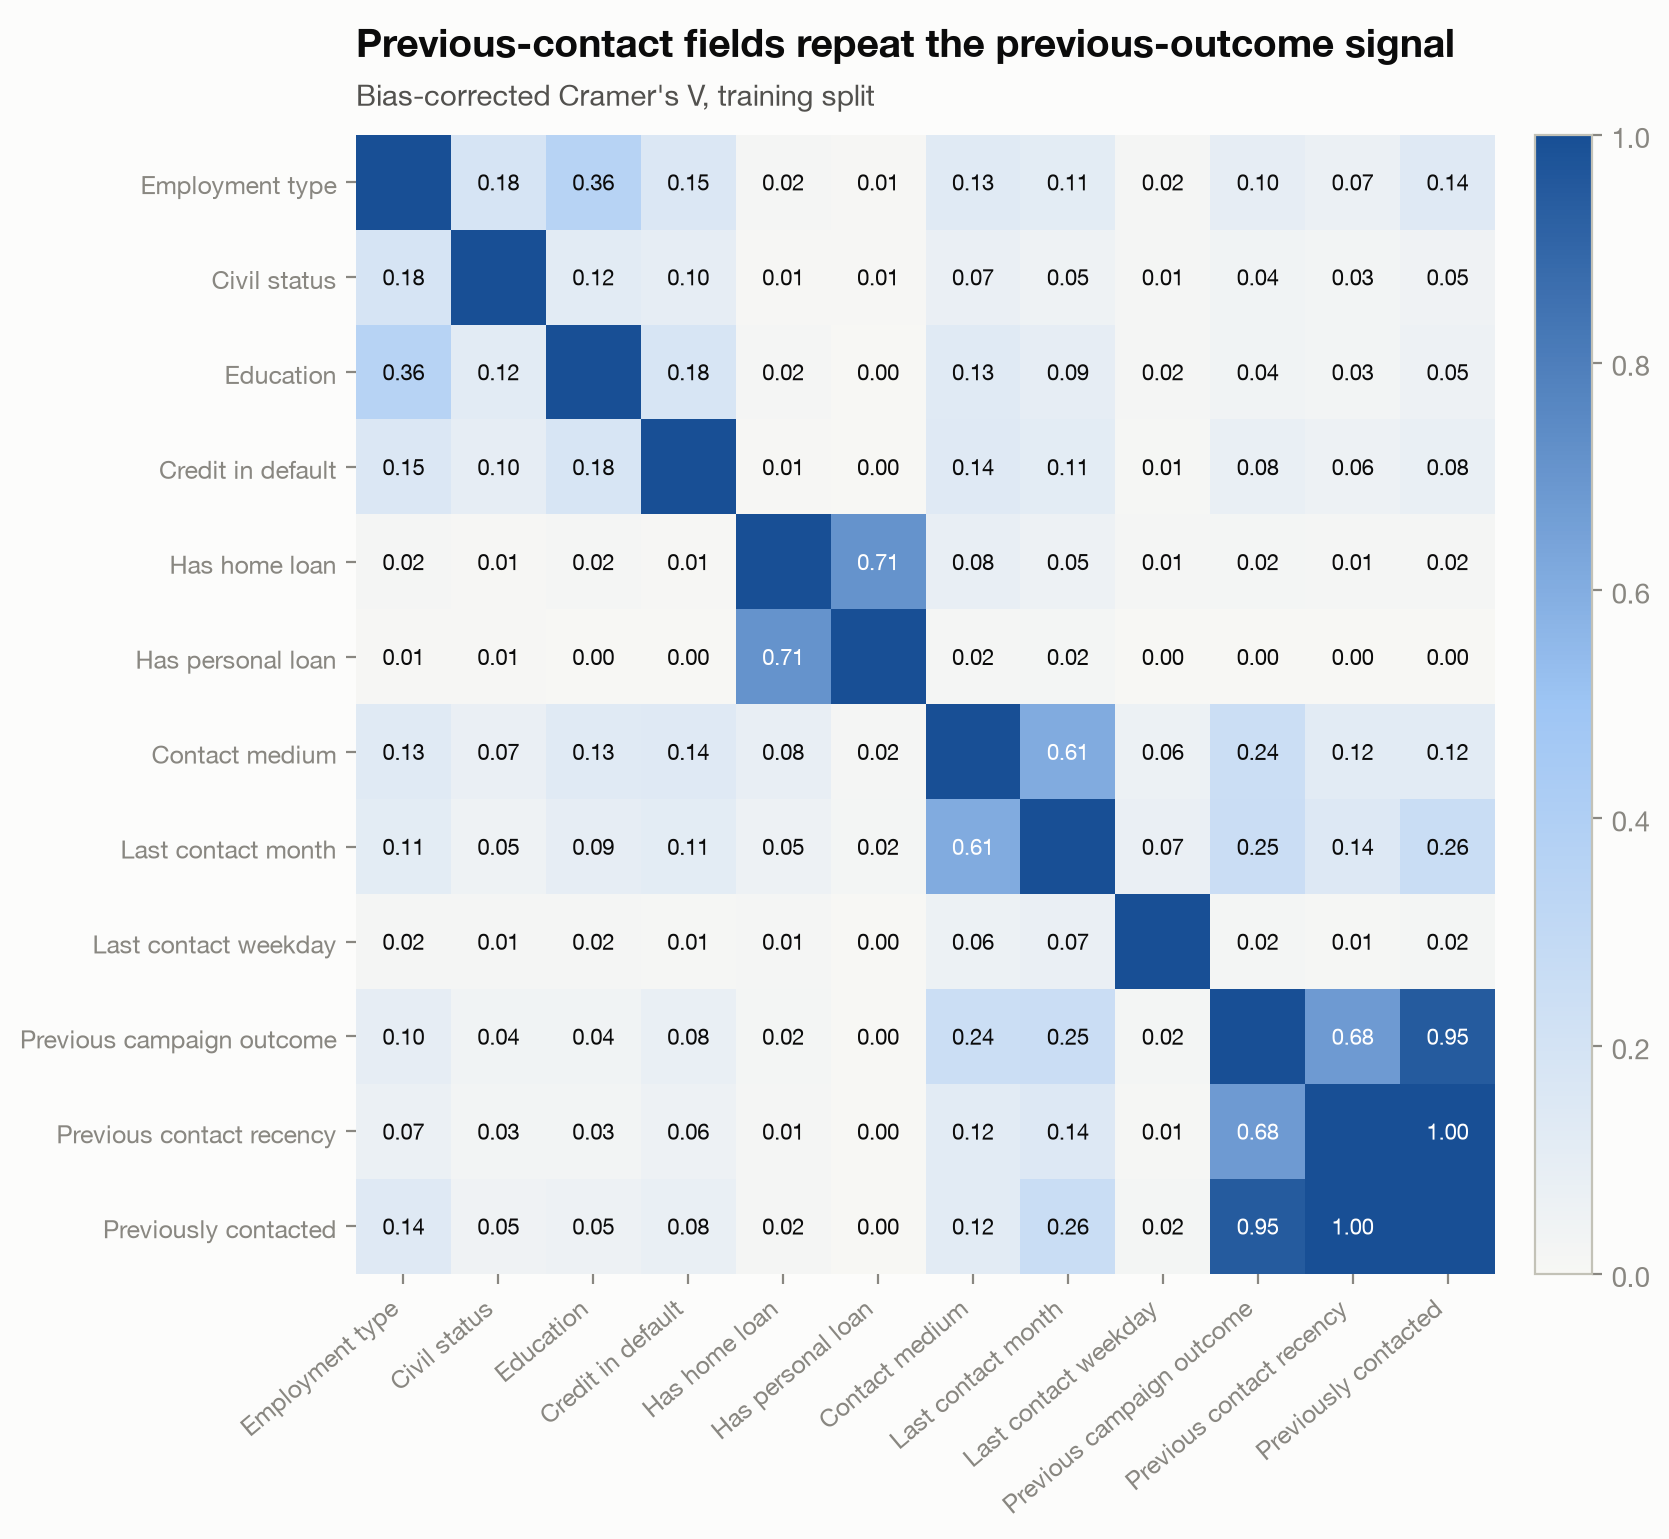

In [10]:
show("04_spearman_numeric.png", 640)
show("05_cramers_v_categorical.png", 700)

## 5. Should the response classes be balanced?

Take-up is 11.2%. The data is **not** resampled, for three reasons:
- Resampling distorts predicted probabilities.
- The profit cut-off relies on calibrated probabilities.
- The evaluation metrics already handle imbalance: PR-AUC, lift, KS and profit.

Class weights were not needed; the cut-off does the balancing.

In [11]:
json.loads((R / "data_summary.json").read_text())

{'rows': 34989,
 'take_up_rate': 0.11229243476521192,
 'features_selected': ['number_of_employees',
  'consumer_confidence_index',
  'prev_contact_recency',
  'previous_outcome',
  'last_contact_month',
  'consumer_price_index',
  'contact_medium',
  'prev_campaign_attempts',
  'employment_type',
  'age',
  'credit_in_default',
  'education',
  'call_attempts',
  'civil_status']}

## 6. Different scales, encoding, grouping and binning

| Question | Logistic models | Tree models |
|---|---|---|
| Different scales | Standardised (one-hot model), or WoE puts every input on the log-odds scale | Not needed |
| Categorical encoding | WoE (scorecard) or one-hot | One-hot |
| Grouping | Levels below 1% of training rows are merged into "Other (rare)" | Same |
| Binning numerics | Yes for the scorecard: decile bins capture non-linear effects such as age | No; trees find their own splits |

All encoders are fitted on training folds only.

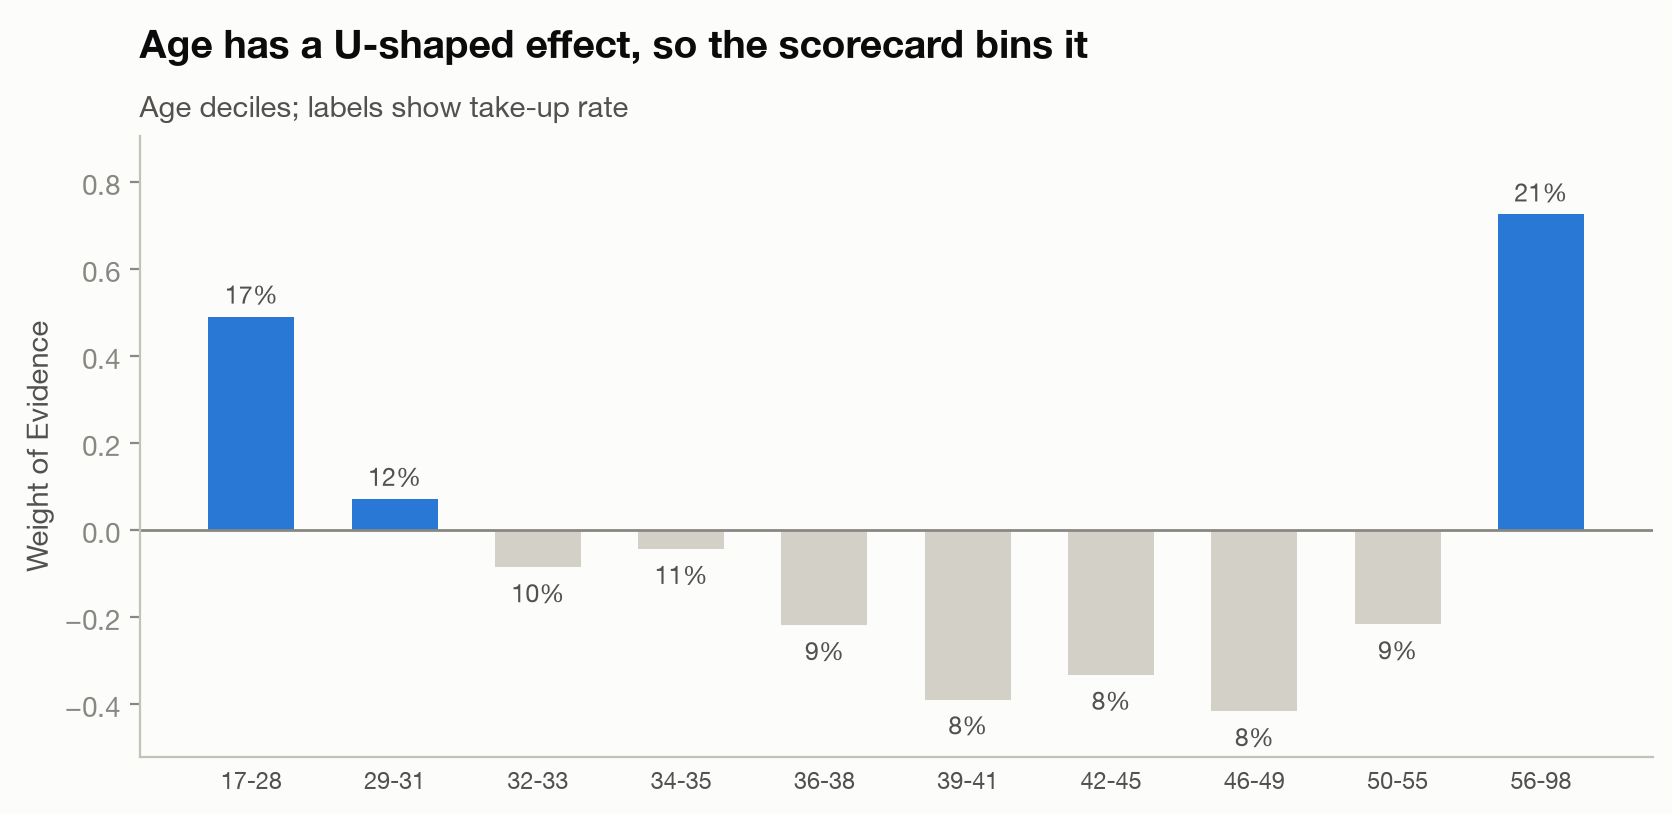

In [12]:
show("06_woe_age.png")

## 7. Train/test split and validation checks while training

- **Split.** 70/30, stratified on the response. The test set is scored once, at the end.
- **Validation.** Every model is validated with 5-fold stratified CV on the training data. Preprocessing is
  re-fitted inside each fold.
- **Tuning.** Uses its own 3-fold CV.
- **Cut-off.** Chosen on out-of-fold training scores.
- **Campaign periods.** A grouped CV holds out whole periods (section 15).

## 8. Choosing the best model (at least one non-linear)

The model ladder has six rungs:
1. baseline;
2. business rule;
3. WoE logistic scorecard;
4. one-hot logistic regression;
5. **random forest** (non-linear);
6. **LightGBM** (non-linear).

Models are ranked on CV PR-AUC (the primary metric), with Gini, KS, top-decile lift and Brier score reported
alongside.

In [13]:
cv = pd.read_csv(R / "cv_summary.csv")
cv[["model", "pr_auc_mean", "pr_auc_std", "gini_mean", "ks_mean", "lift_top10_mean", "brier_mean",
    "overfit_gap_pr_auc"]]

,model,pr_auc_mean,pr_auc_std,gini_mean,ks_mean,lift_top10_mean,brier_mean,overfit_gap_pr_auc
0,Baseline (response rate),0.1123,0.0000,0.0000,0.0000,0.9670,0.0997,-0.0000
1,Business rule (previous outcome),0.2552,0.0221,0.3480,0.2311,2.6900,0.1000,-0.0006
2,Logistic scorecard (WoE),0.4233,0.0298,0.5658,0.4813,4.2022,0.0803,0.0017
3,Logistic regression (one-hot),0.4392,0.0296,0.5606,0.4780,4.2859,0.0794,0.0070
4,Random forest,0.4532,0.0272,0.5680,0.4851,4.3840,0.0783,0.0591
5,LightGBM,0.4452,0.0269,0.5574,0.4809,4.3695,0.0789,0.1584
6,Random forest (tuned),0.4540,0.0245,0.5742,0.4864,4.4131,0.0779,0.0712
7,LightGBM (tuned),0.4583,0.0278,0.5774,0.4877,4.4422,0.0778,0.0415


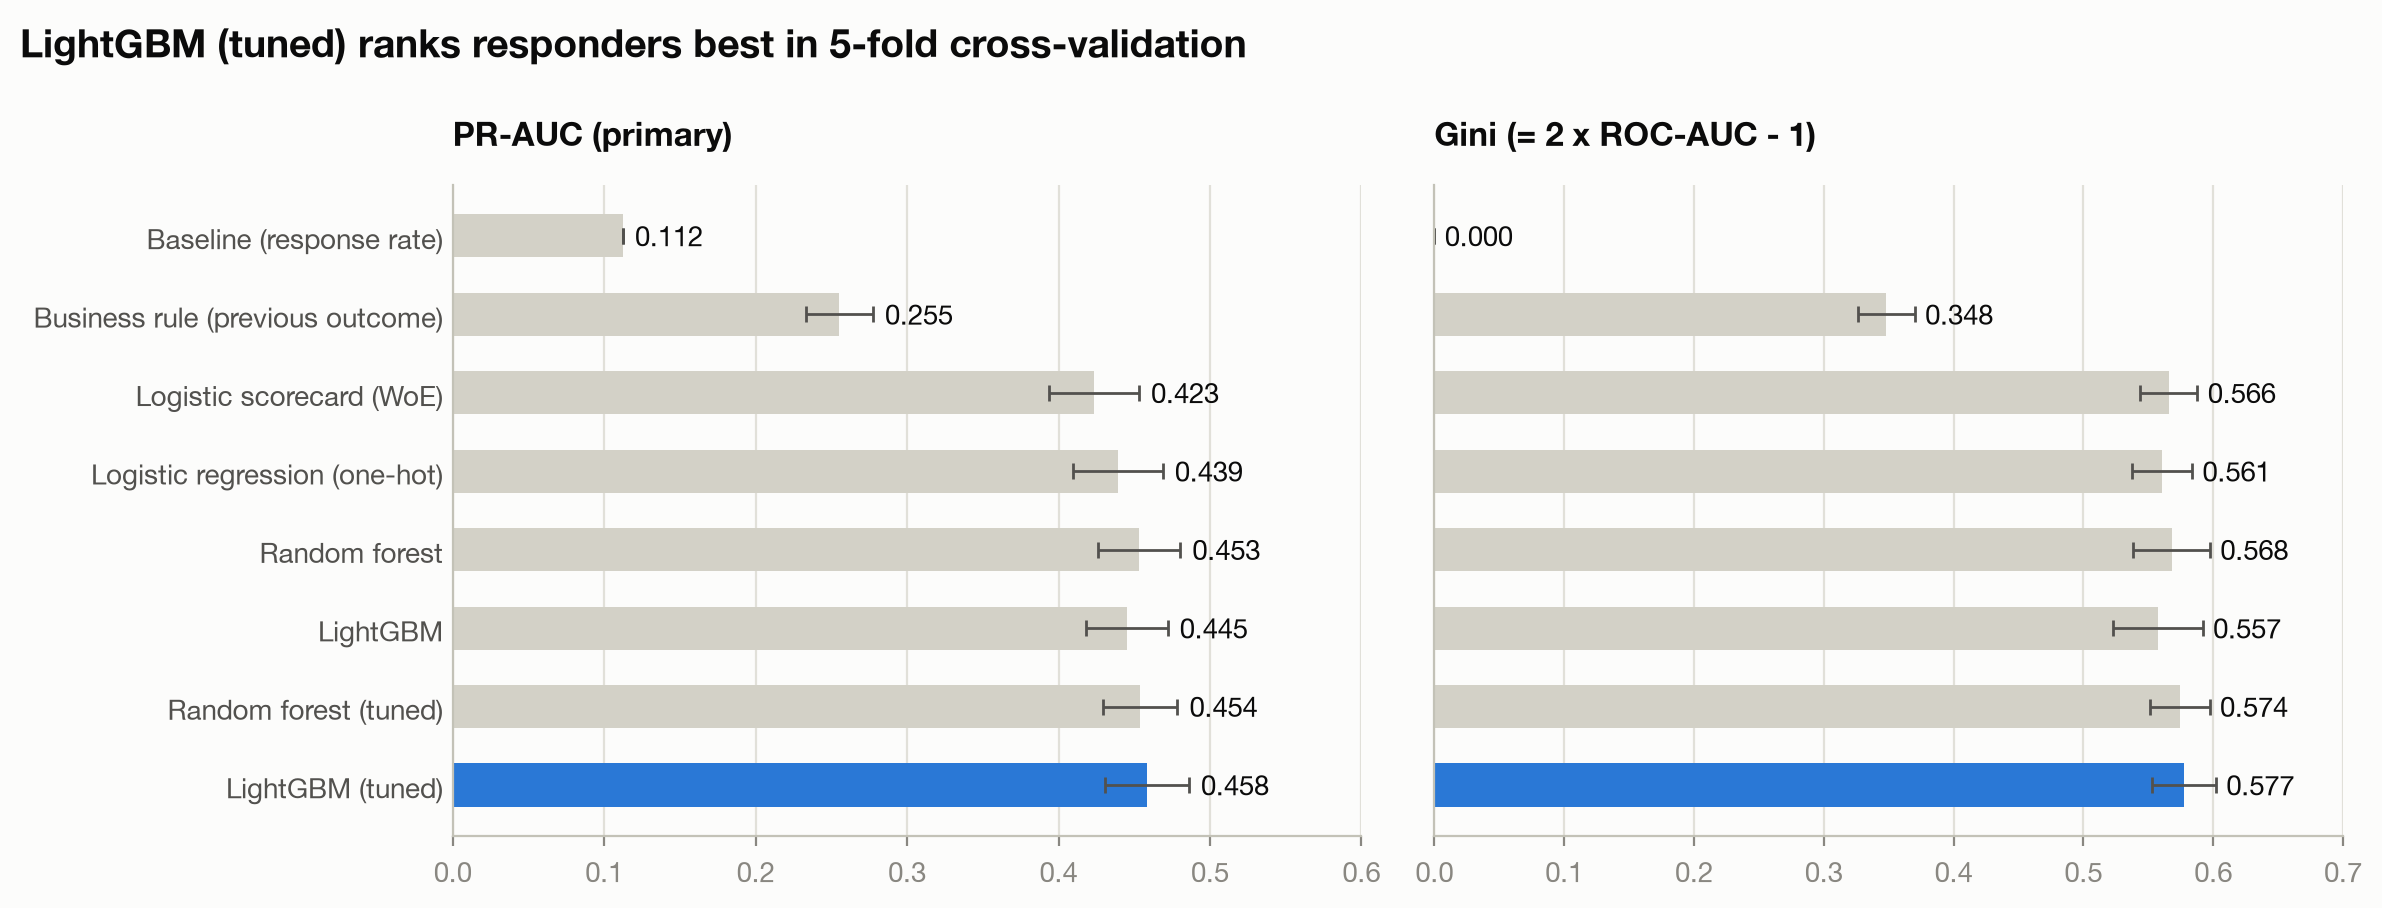

In [14]:
show("10_model_ladder_cv.png", 900)

## 9. Which models to optimise, and how

The two best untuned models on CV PR-AUC go forward and are both tuned with a randomised search (25 candidates,
3-fold CV, scored on PR-AUC):
- **Randomised search** covers a large, mixed parameter space efficiently.
- **PR-AUC** is the target because the business needs a clean top of the call list.

The tuned finalist with the higher 5-fold CV PR-AUC is selected. The table after the search results compares
models fold by fold: the non-linear models effectively tie, and tuning reuses the training folds (no nested CV),
so the small tuning gains should not be over-read.

In [15]:
json.loads((R / "best_params.json").read_text())

{'model': 'LightGBM (tuned)',
 'model__colsample_bytree': 0.8238450602706812,
 'model__learning_rate': 0.010011989304553251,
 'model__min_child_samples': 22,
 'model__n_estimators': 508,
 'model__num_leaves': 13,
 'model__reg_lambda': 1.8415478124479583,
 'model__subsample': 0.7669644012595116}

In [16]:
pd.read_csv(R / "cv_paired_differences.csv")

,model,pr_auc_diff_mean,pr_auc_diff_std,reference_wins,folds
0,Random forest (tuned),0.0042,0.0039,4,5
1,Random forest,0.0051,0.0032,5,5
2,LightGBM,0.0131,0.0032,5,5
3,Logistic regression (one-hot),0.0191,0.0081,5,5
4,Logistic scorecard (WoE),0.0350,0.0111,5,5
5,Business rule (previous outcome),0.2030,0.0125,5,5
6,Baseline (response rate),0.3460,0.0278,5,5


In [17]:
pd.read_csv(R / "tuning_results.csv")[["model", "rank_test_score", "mean_test_score", "std_test_score"]] \
    .sort_values(["model", "rank_test_score"]).groupby("model").head(3)

,model,rank_test_score,mean_test_score,std_test_score
0,LightGBM,1,0.4577,0.0169
1,LightGBM,2,0.4533,0.0166
2,LightGBM,3,0.4530,0.0162
25,Random forest,1,0.4539,0.0139
26,Random forest,2,0.4534,0.0158
27,Random forest,3,0.4530,0.0161


## 10. Guarding against over- and underfitting

Four checks:
- the gap between training-fold and validation-fold scores;
- a learning curve;
- the LightGBM boosting curve (validation loss by round);
- score stability between the out-of-fold and test samples (Population Stability Index, PSI).

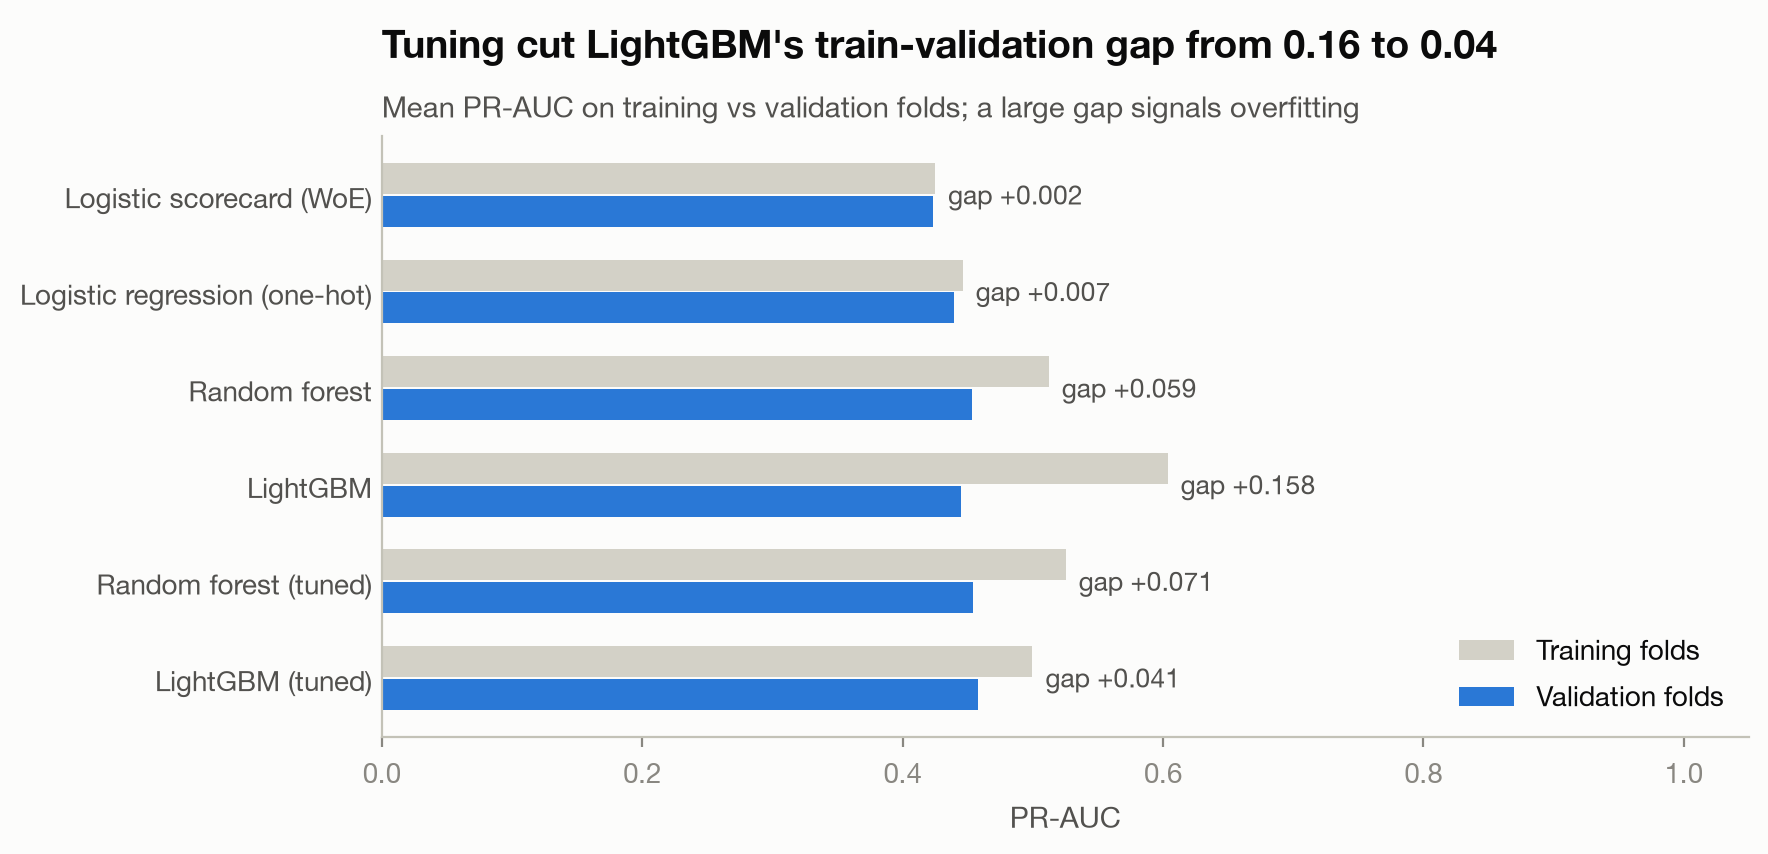

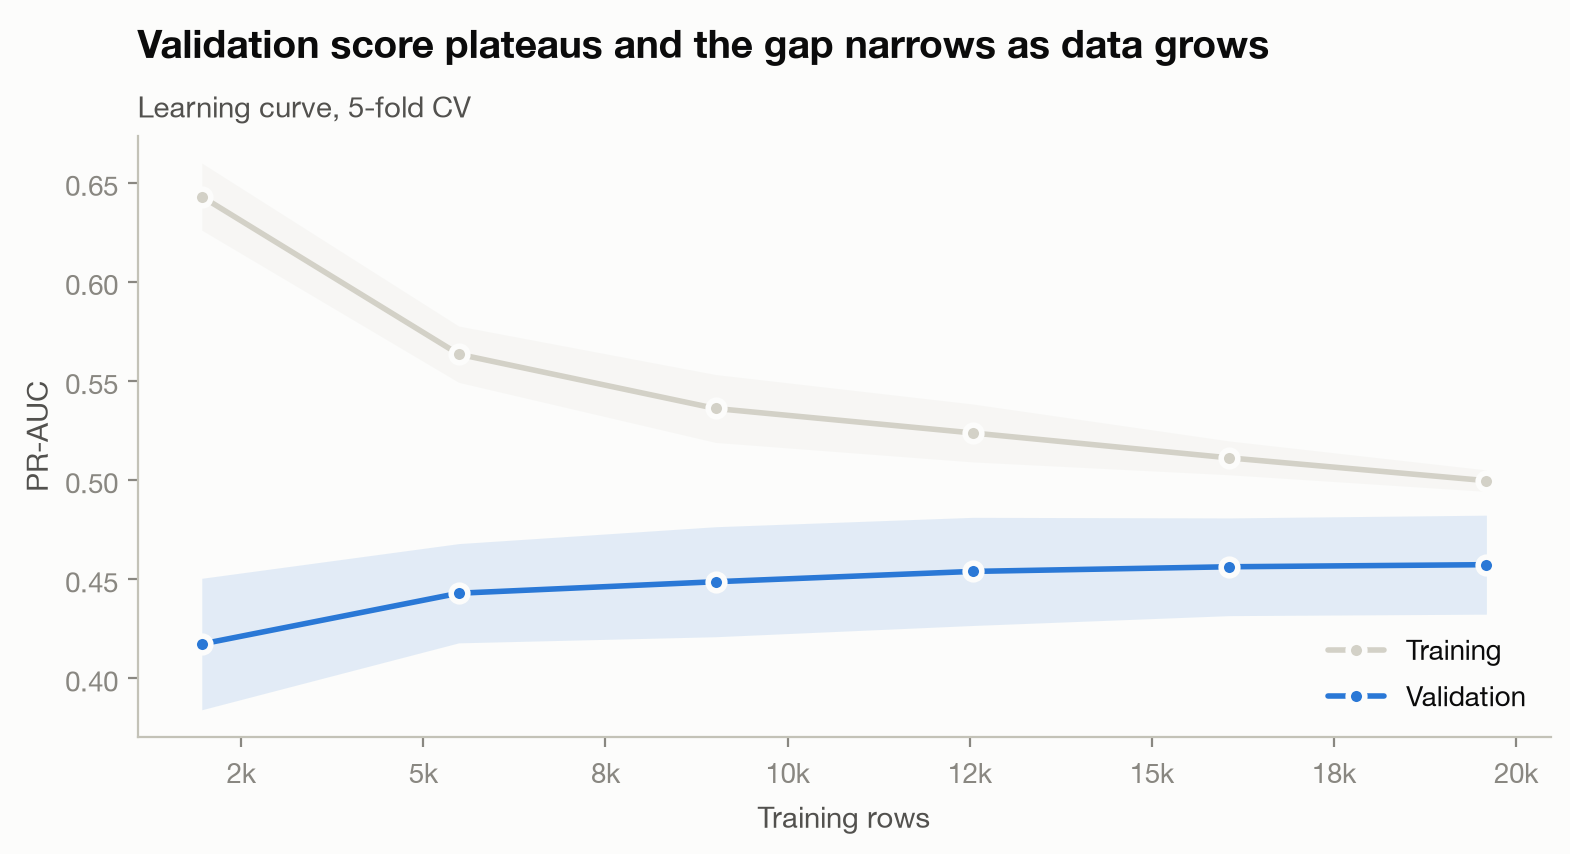

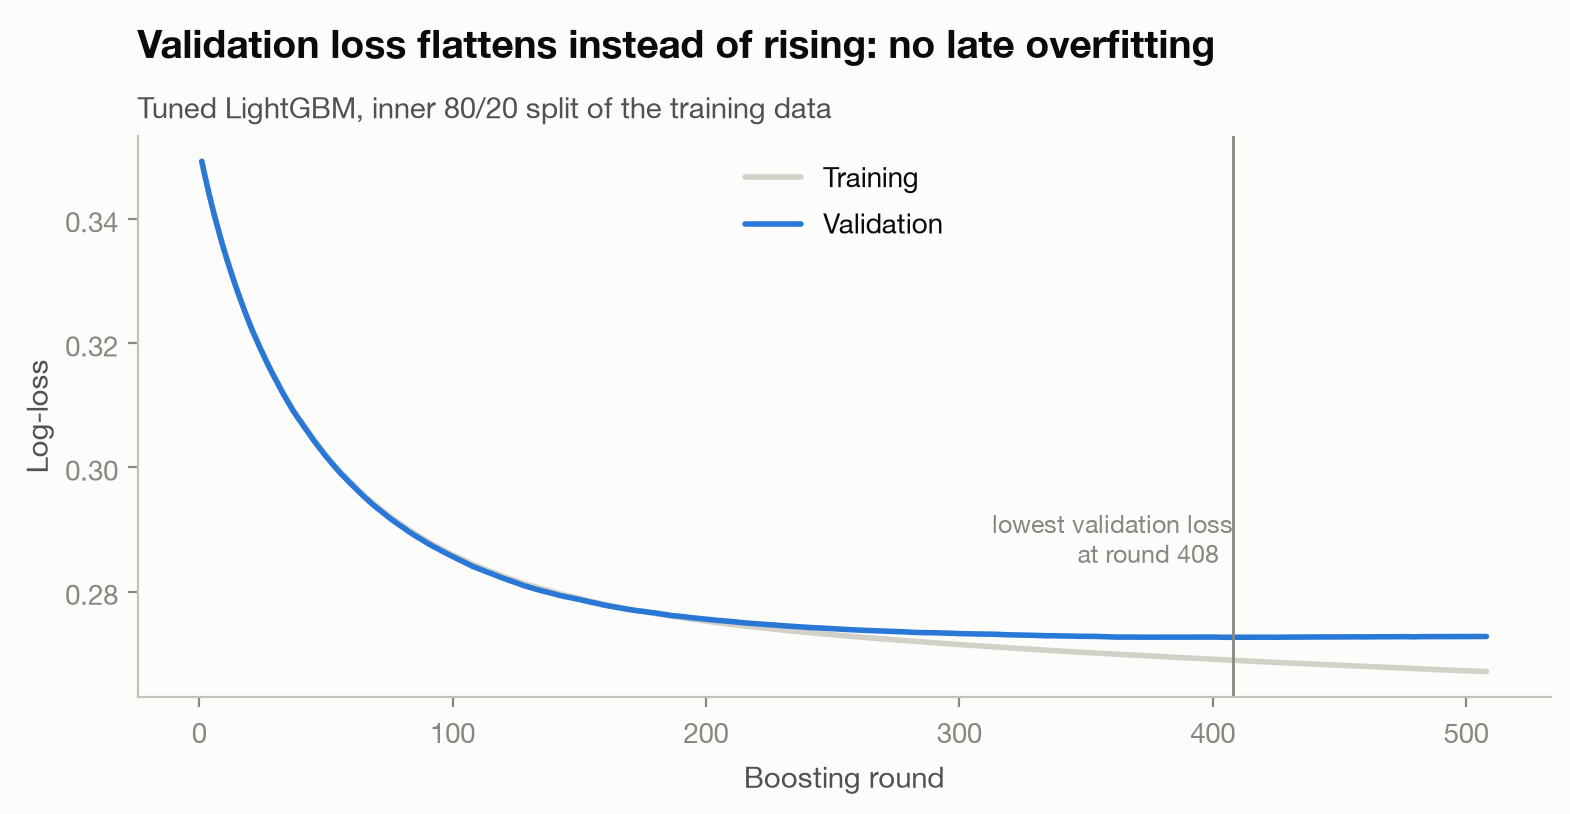

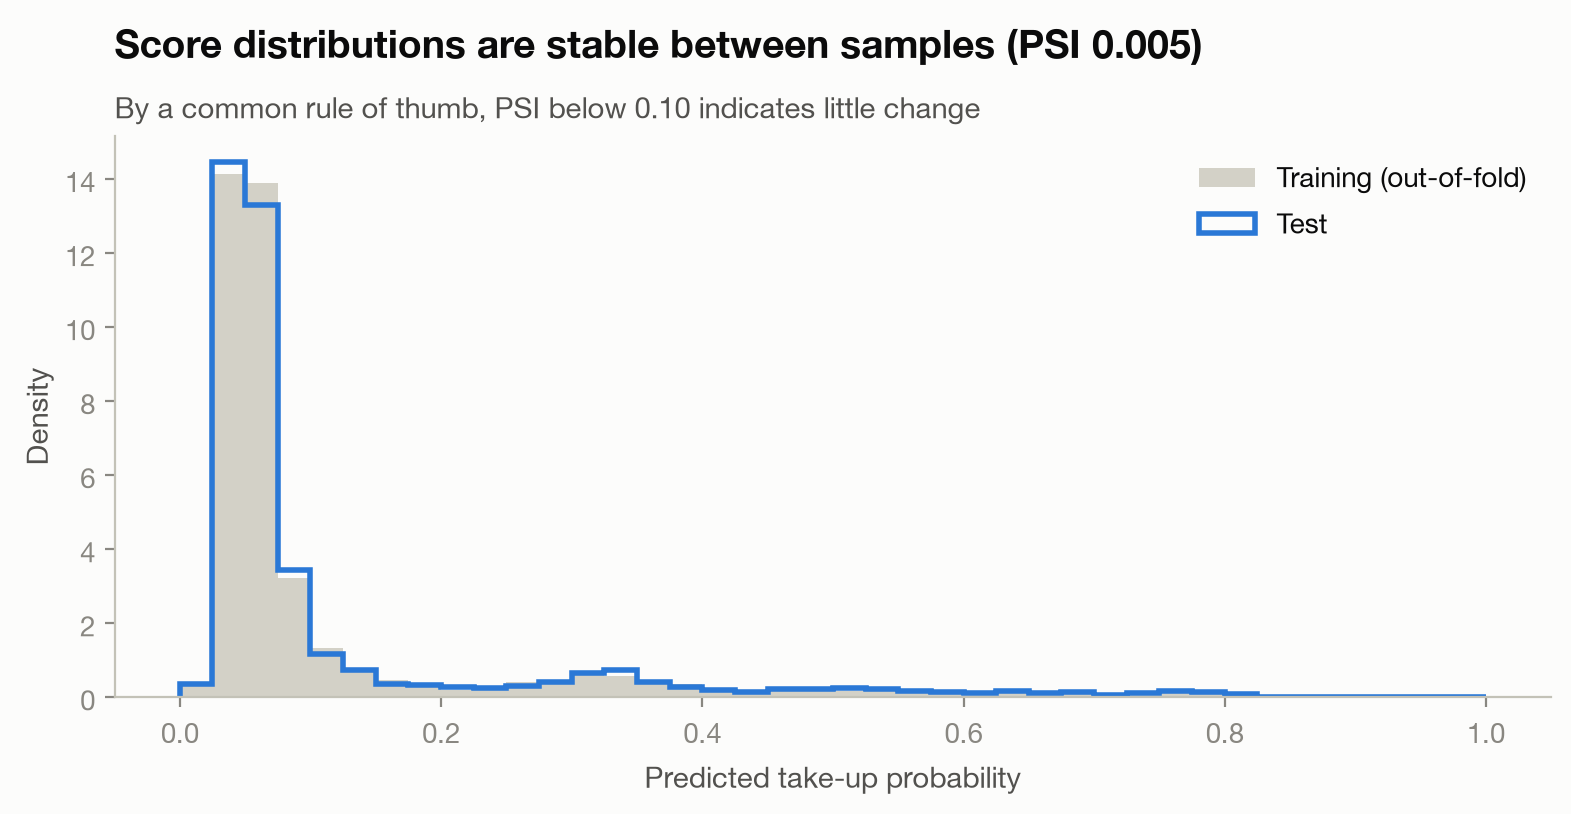

In [18]:
for f in ["11_train_vs_validation.png", "12_learning_curve.png", "13_boosting_curve.png", "19_score_stability.png"]:
    if (F / f).exists():
        show(f, 760)

## 11. Interpreting the predictors, and most and least important inputs

- **SHAP** shows how the selected model uses each input.
- **Permutation importance** shows how much the test PR-AUC drops when an input is shuffled.
- **Scorecard coefficients** give the WoE model's view.

The least important inputs are listed at the bottom of each table.

In [19]:
display(pd.read_csv(R / "shap_importance.csv"))
display(pd.read_csv(R / "permutation_importance.csv"))
display(pd.read_csv(R / "scorecard_coefficients.csv"))

,feature,mean_abs_shap
0,number_of_employees,0.3747
1,contact_medium,0.1652
2,consumer_confidence_index,0.1144
3,last_contact_month,0.0706
4,prev_contact_recency,0.0684
5,age,0.0645
6,previous_outcome,0.0644
7,education,0.0524
8,credit_in_default,0.0516
9,call_attempts,0.0490


,feature,pr_auc_drop,std
0,number_of_employees,0.1780,0.0048
1,contact_medium,0.0291,0.0027
2,prev_contact_recency,0.0259,0.0044
3,consumer_confidence_index,0.0135,0.0011
4,last_contact_month,0.0132,0.0012
5,call_attempts,0.0120,0.0032
6,previous_outcome,0.0117,0.0036
7,consumer_price_index,0.0055,0.0010
8,age,0.0033,0.0013
9,credit_in_default,0.0021,0.0006


,feature,coefficient
0,number_of_employees,0.6622
1,prev_contact_recency,0.6575
2,call_attempts,0.3245
3,contact_medium,0.3005
4,last_contact_month,0.2927
5,age,0.2851
6,credit_in_default,0.2826
7,education,0.2306
8,civil_status,0.1694
9,employment_type,0.1509


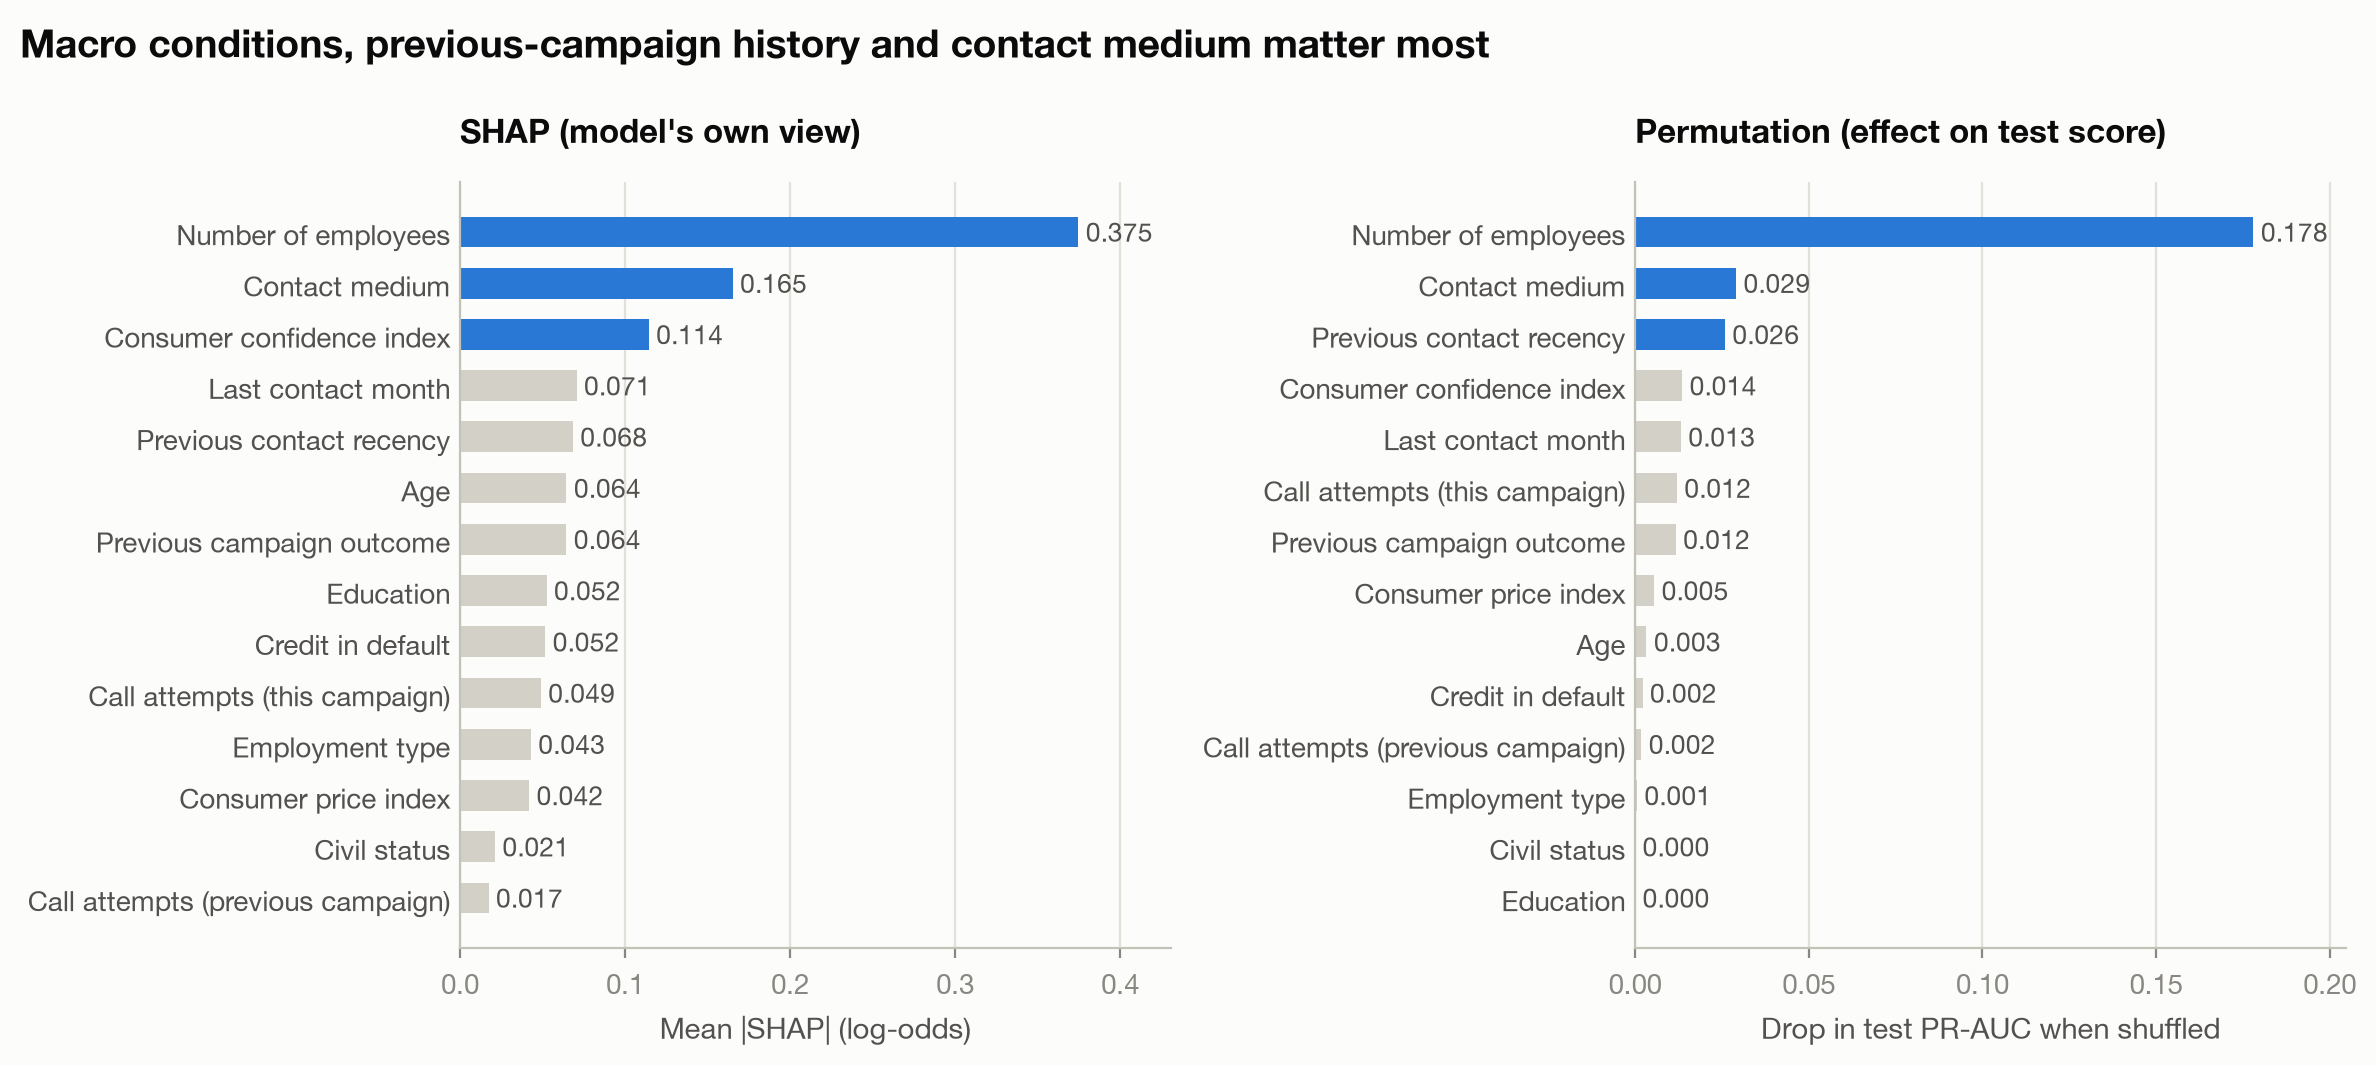

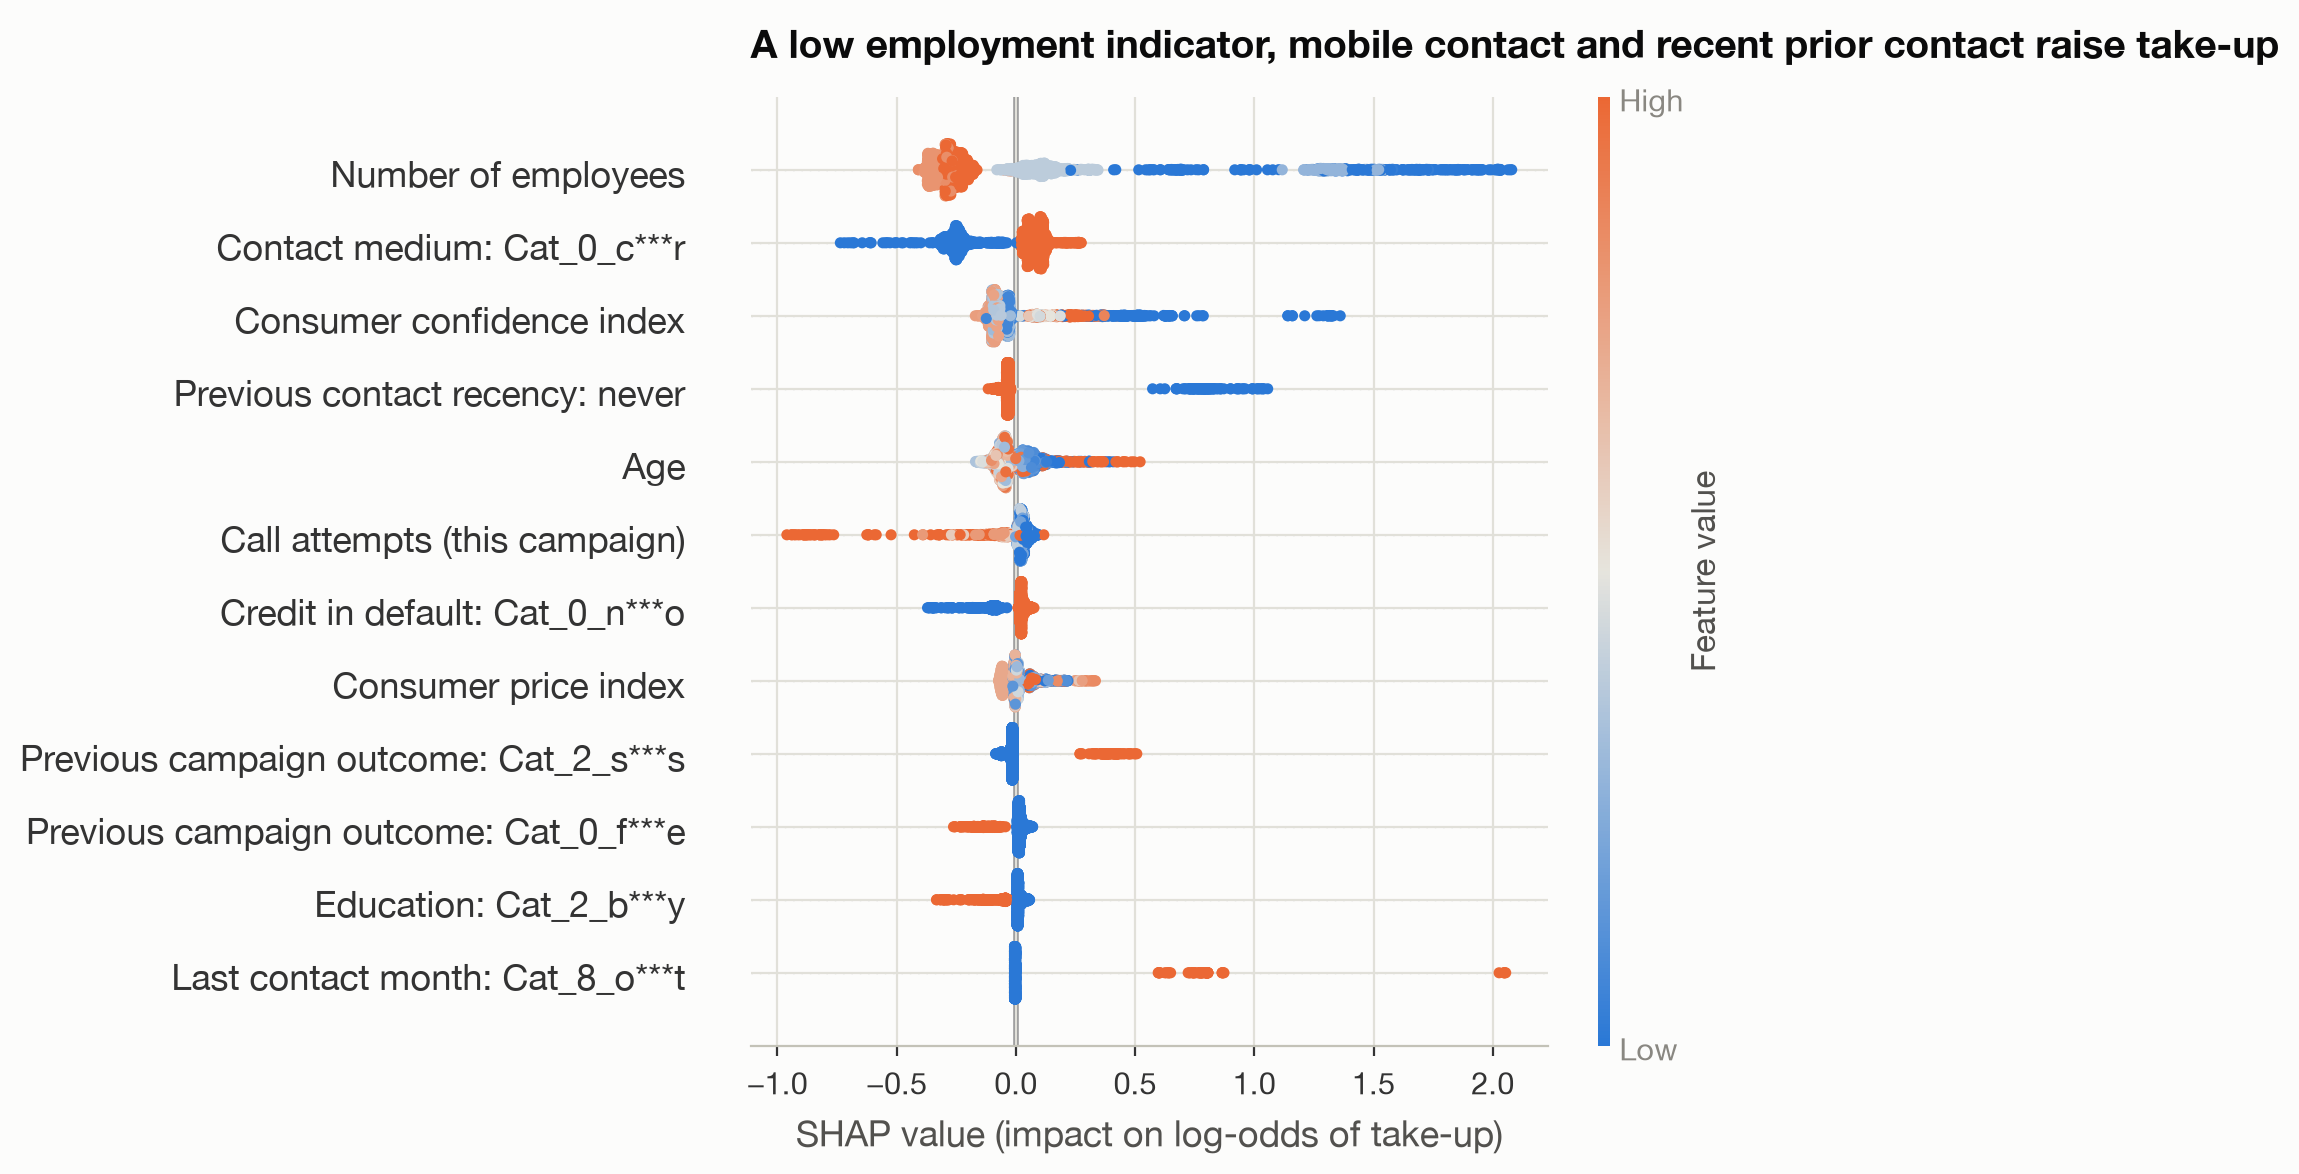

In [20]:
show("20_feature_importance.png", 900)
show("21_shap_beeswarm.png", 760)

## 12. Choosing the cut-off

Finance's figures give the economics:
- A take-up is worth **1,001** on average, weighting High, Medium and Low risk by 10%, 25% and 65%.
- A call that does not convert costs **300**.

Calling is worthwhile when p × 1,001 > (1 − p) × 300, i.e. p > 0.231 (Elkan, 2001). The cut-off that
maximises profit on out-of-fold scores is used, and compared with 0.5, the F1-optimal and the Youden-J cut-offs.
The profit curve is flat near its peak (388.3k at 0.20, 386.4k at 0.23), so the exact choice matters little.

In [21]:
json.loads((R / "thresholds.json").read_text())

{'f1_optimal': 0.204350696193558,
 'youden_j': 0.11644545748272042,
 'default_0_5': 0.5,
 'base_rate': 0.11228156132614732,
 'break_even': 0.23059185242121444,
 'profit_optimal_oof': 0.2}

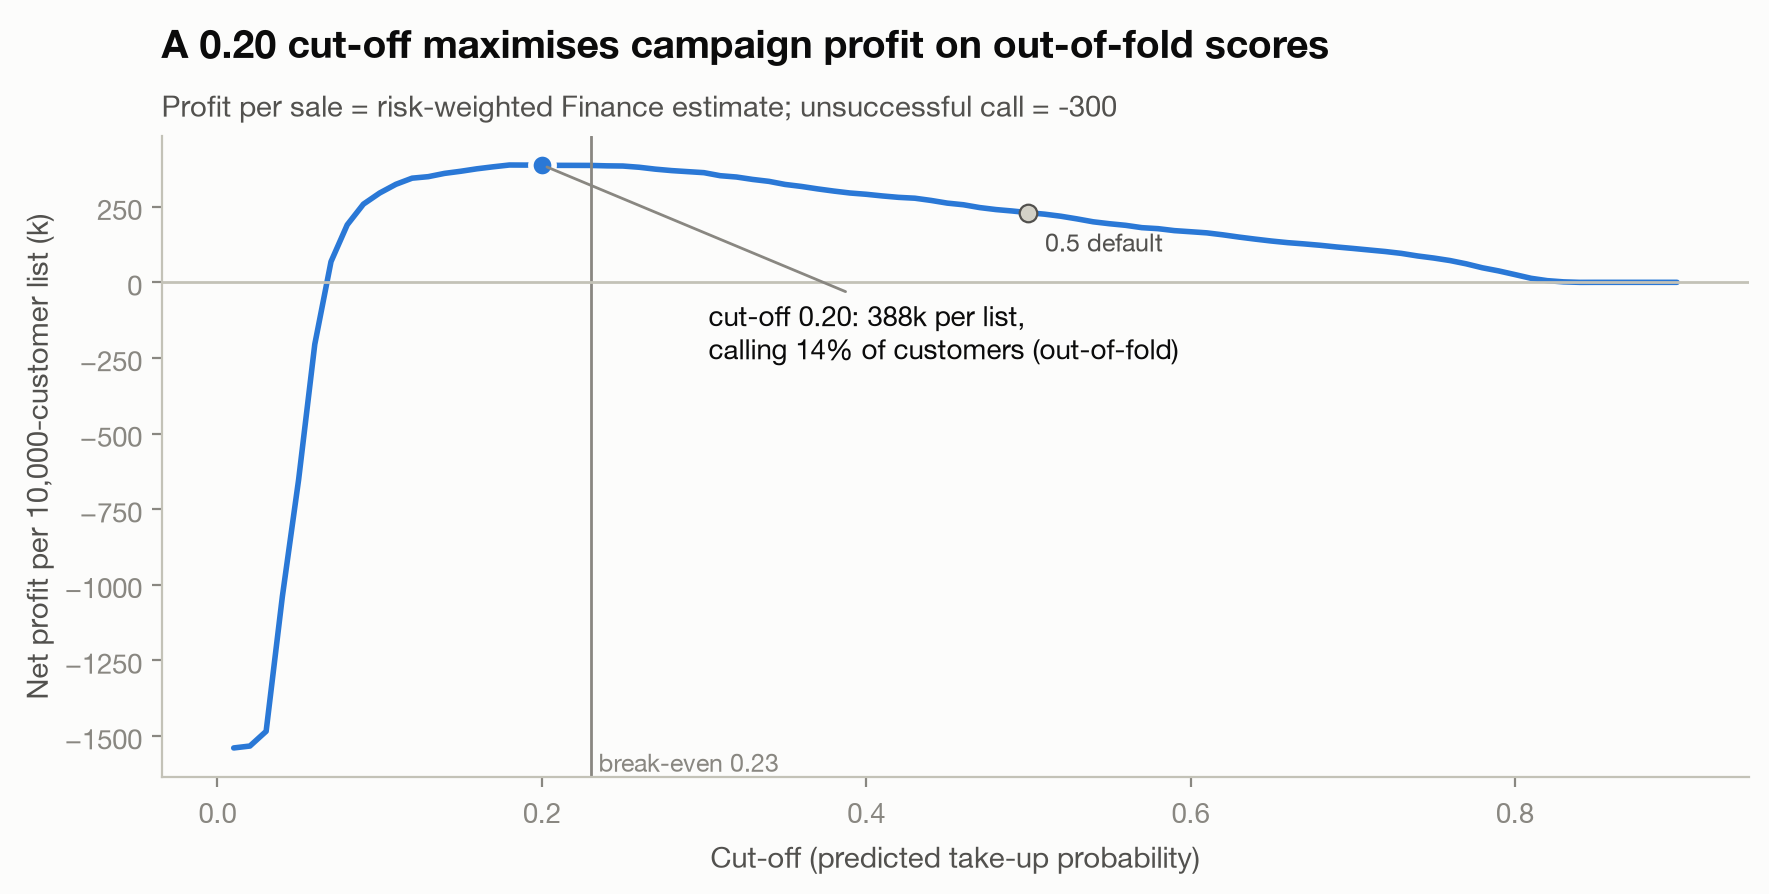

In [22]:
show("14_profit_vs_cutoff.png")

## 13. Final model on the held-out test set

In [23]:
m = json.loads((R / "test_metrics.json").read_text())
pd.Series({k: v for k, v in m.items() if not isinstance(v, dict)})

threshold                          0.2000
pr_auc                             0.4675
roc_auc                            0.8098
gini                               0.6196
ks                                 0.5151
brier                              0.0766
lift_top10                         4.5280
precision                          0.4421
recall                             0.5802
f1                                 0.5018
specificity                        0.9074
accuracy                           0.8706
call_rate                          0.1474
tp                                    684
fp                                    863
tn                                   8455
fn                                    495
n                                   10497
base_rate                          0.1123
model                    LightGBM (tuned)
psi_train_oof_vs_test              0.0046
value_per_sale                 1,001.0000
dtype: object

In [24]:
pd.DataFrame(m["alternative_cutoffs_test"]).T

,threshold,precision,recall,call_rate,tp,fp,tn,fn
f1_optimal,0.2044,0.4455,0.5759,0.1452,679.0000,845.0000,"8,473.0000",500.0000
youden_j,0.1164,0.3792,0.6480,0.1920,764.0000,"1,251.0000","8,067.0000",415.0000
default_0_5,0.5000,0.6403,0.2612,0.0458,308.0000,173.0000,"9,145.0000",871.0000
break_even,0.2306,0.4516,0.5581,0.1388,658.0000,799.0000,"8,519.0000",521.0000
profit_optimal_oof,0.2000,0.4421,0.5802,0.1474,684.0000,863.0000,"8,455.0000",495.0000


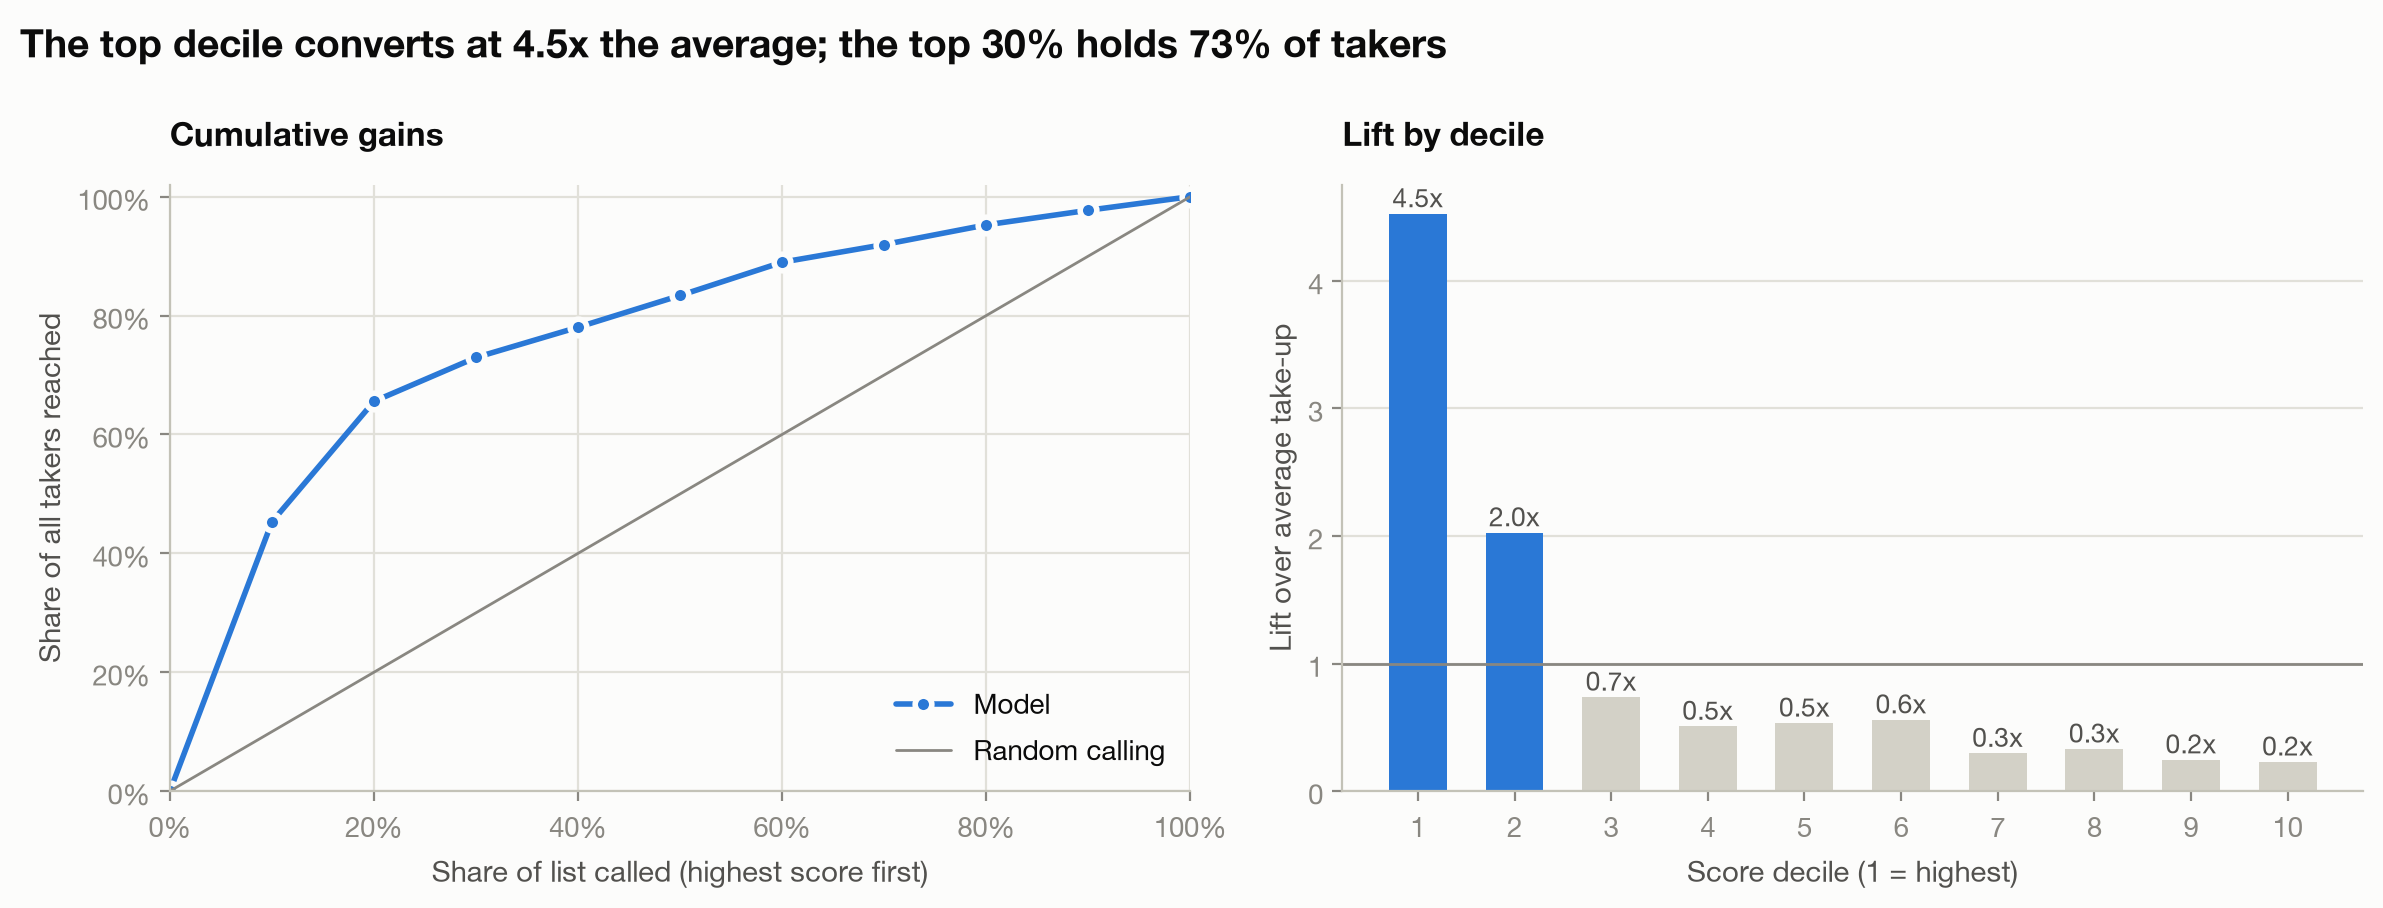

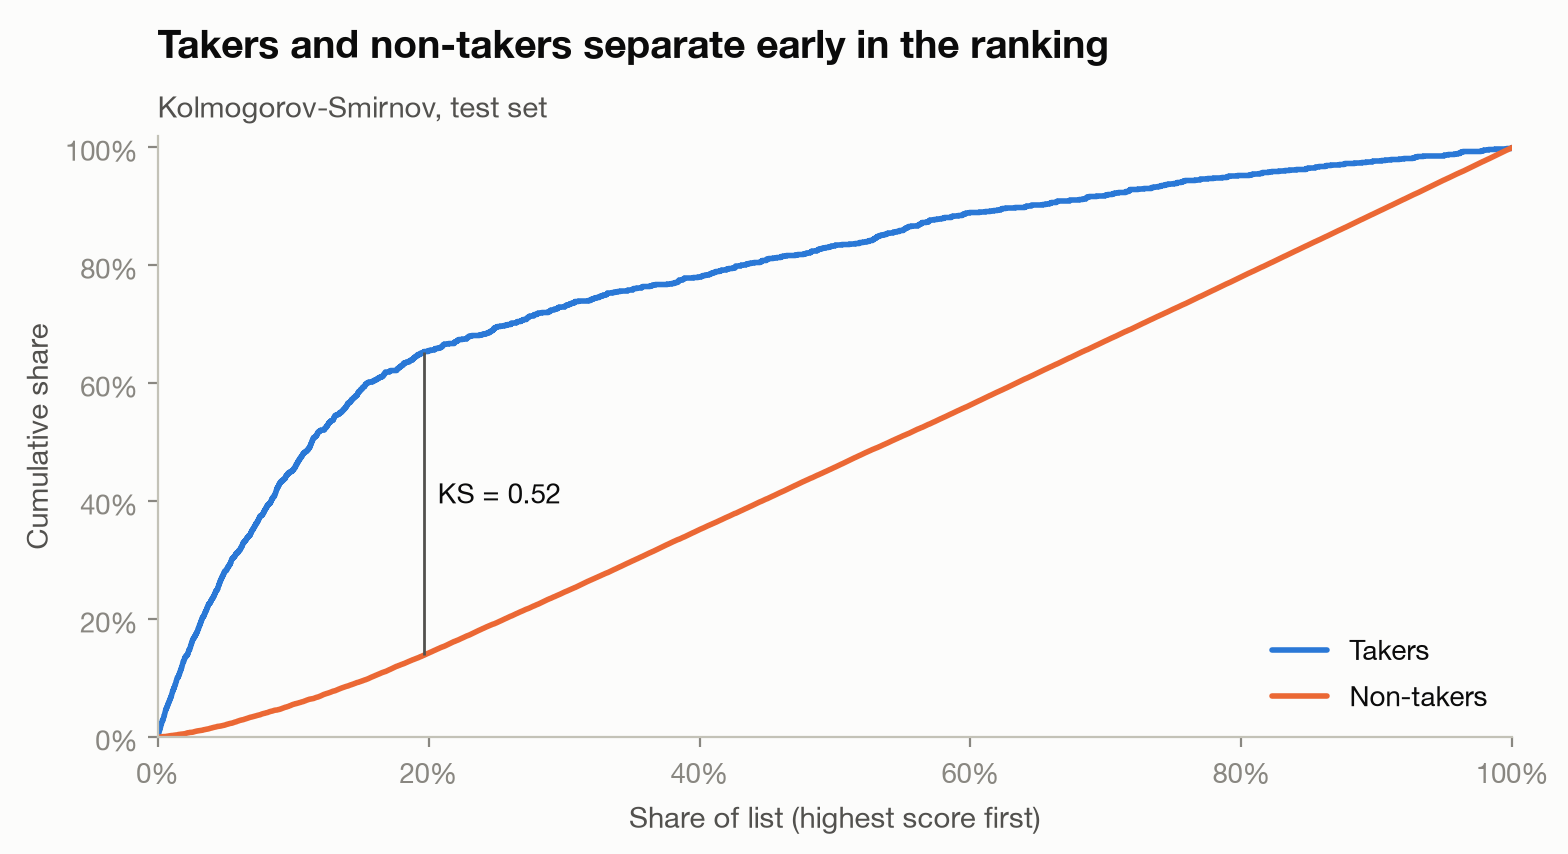

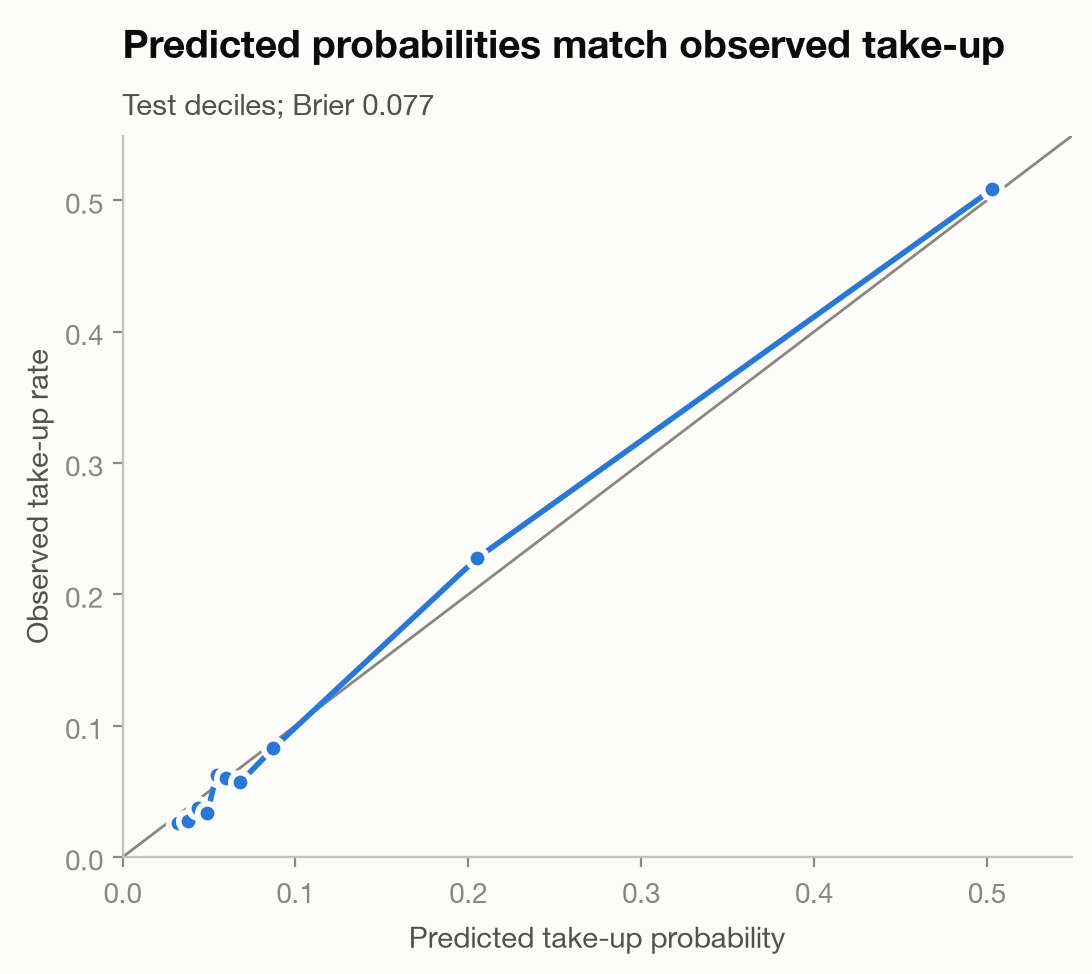

,decile,customers,responders,response_rate,cumulative_share_of_responders,lift
0,1,1050,534,0.5086,0.4529,4.5280
1,2,1050,239,0.2276,0.6556,2.0266
2,3,1050,87,0.0829,0.7294,0.7377
3,4,1049,60,0.0572,0.7803,0.5092
4,5,1050,63,0.0600,0.8338,0.5342
5,6,1050,66,0.0629,0.8897,0.5596
6,7,1049,35,0.0334,0.9194,0.2971
7,8,1050,39,0.0371,0.9525,0.3307
8,9,1050,29,0.0276,0.9771,0.2459
9,10,1049,27,0.0257,1.0000,0.2292


In [25]:
for f in ["15_gains_lift.png", "16_ks.png", "17_calibration.png"]:
    show(f, 820)
pd.read_csv(R / "gains_table.csv")

## 14. Reading the confusion matrix

- **True positives:** called, and took up the offer; this is revenue.
- **False positives:** called, but did not take up; each costs 300.
- **False negatives:** not called, but would have taken up; this is missed profit.
- **True negatives:** not called, and would not have taken up; the call cost is saved.

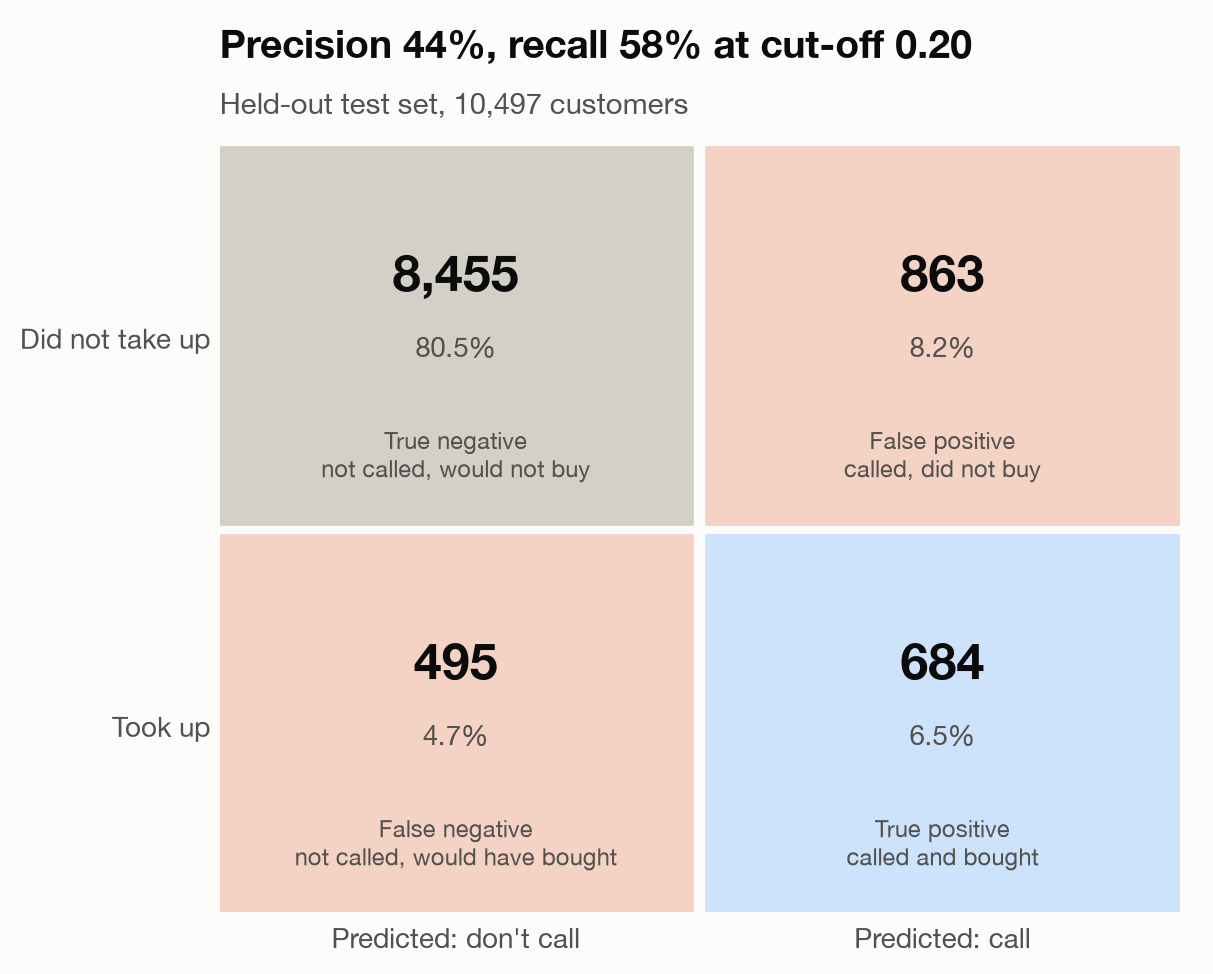

In [26]:
show("18_confusion_matrix.png", 600)

## 15. Campaign periods: when versus whom

The four macro indicators take one value combination per campaign period (26 periods, one contact month each), so
a random split tests on periods the model has already seen. Two further checks:
- grouped CV that holds out whole periods;
- ranking *within* a period, since a list is called within one period.

Most of the lift comes from telling good periods from bad ones. Ranking within a period is modest.

In [27]:
display(pd.read_csv(R / "period_validation.csv"))
json.loads((R / "period_summary.json").read_text())

,model,scheme,roc_auc,pr_auc,lift_top10,periods_scored,within_roc_auc,within_lift_top10
0,LightGBM (tuned),Grouped CV (unseen periods),0.7216,0.3389,2.9093,25,0.5595,1.5313
1,LightGBM (tuned),Random split test (seen periods),0.8098,0.4675,4.5280,24,0.5440,1.1549
2,Customer-only LightGBM (no timing inputs),Grouped CV (unseen periods),0.7178,0.3548,3.4912,25,0.5518,1.4135
3,Customer-only LightGBM (no timing inputs),Random split test (seen periods),0.7437,0.3671,3.6885,24,0.5313,1.2666


{'periods': 26,
 'months_per_period_max': 1,
 'periods_with_take_up_above_break_even': 18}

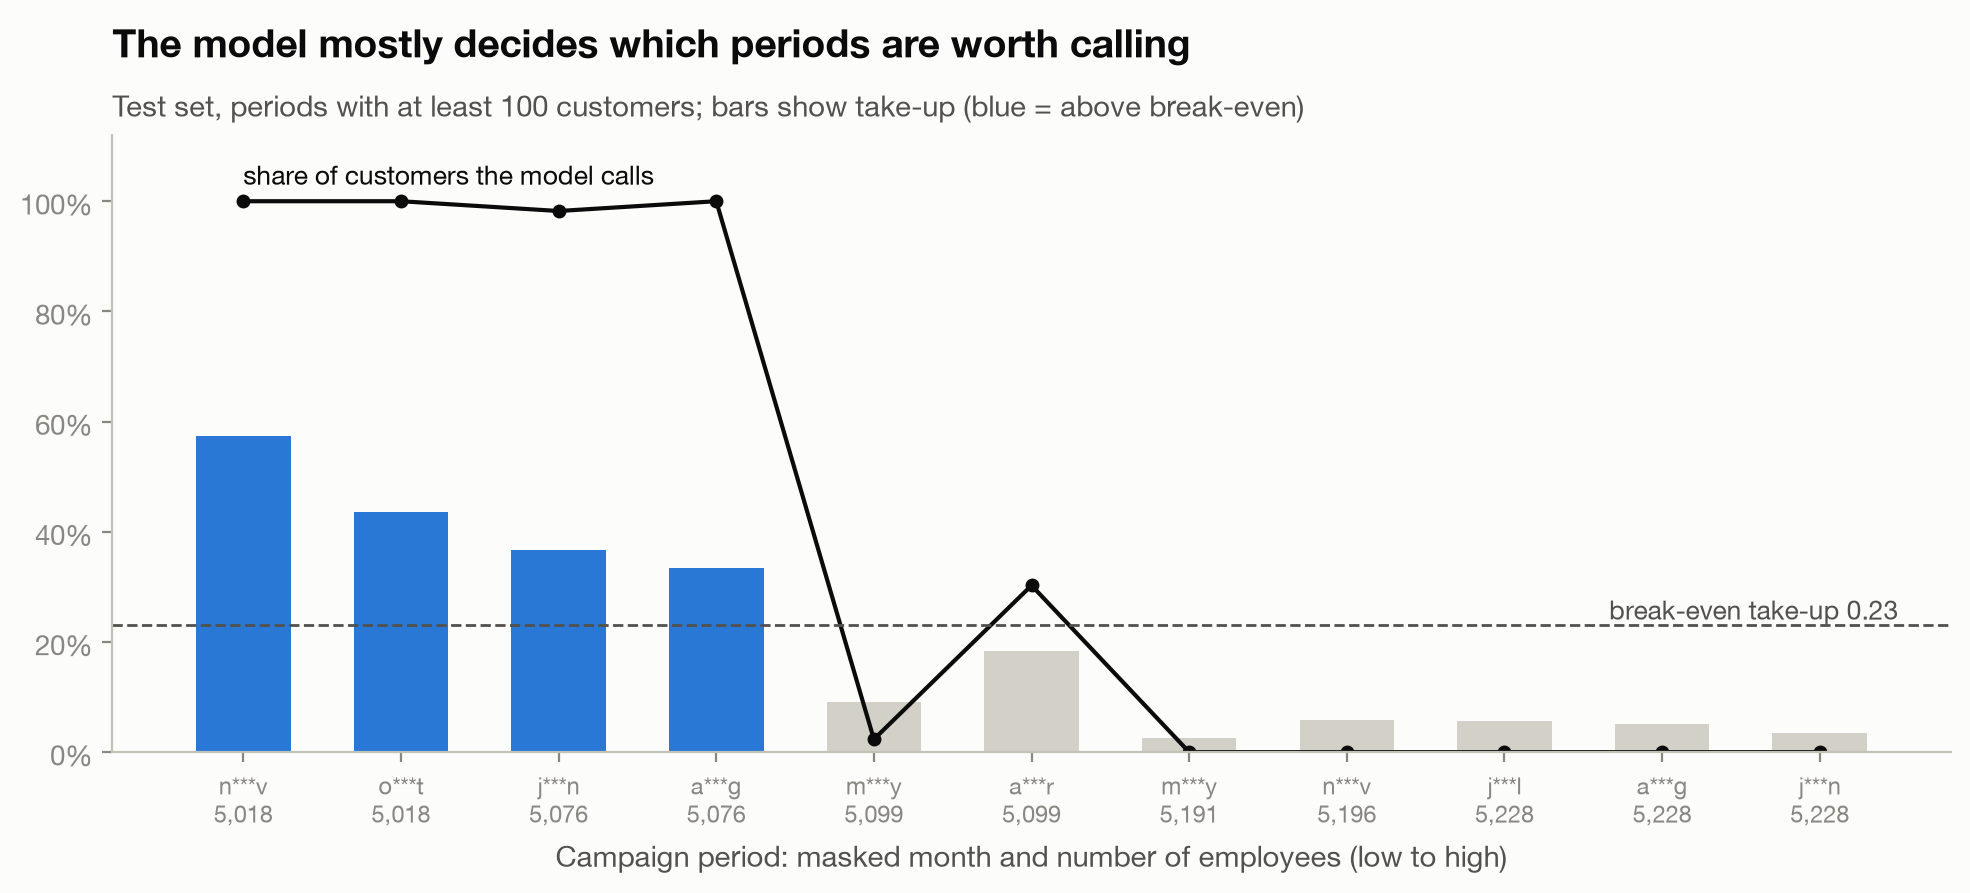

,period,month,number_of_employees,customers,take_up_rate,call_rate,tp,fp,profit_per_10k_model,profit_per_10k_call_all
0,18,Cat_7_n***v,"4,963.6000",35,0.5143,1.0000,18,17,"3,690,857.1429","3,690,857.1429"
1,17,Cat_8_o***t,"4,963.6000",43,0.3721,0.7442,13,19,"1,700,697.6744","1,840,930.2326"
2,16,Cat_9_s***p,"4,963.6000",80,0.4750,0.8375,37,30,"3,504,625.0000","3,179,750.0000"
3,15,Cat_3_j***l,"4,991.6000",78,0.6026,0.8974,46,24,"4,980,256.4103","4,839,358.9744"
4,14,Cat_4_j***n,"4,991.6000",64,0.4375,0.7500,25,23,"2,832,031.2500","2,691,875.0000"
5,13,Cat_1_a***g,"4,991.6000",55,0.5091,0.8364,26,20,"3,641,090.9091","3,623,272.7273"
6,12,Cat_6_m***y,"5,008.7000",57,0.5439,0.9123,29,23,"3,882,280.7018","4,075,614.0351"
7,11,Cat_0_a***r,"5,008.7000",56,0.5536,1.0000,31,25,"4,201,964.2857","4,201,964.2857"
8,10,Cat_5_m***r,"5,008.7000",68,0.5882,1.0000,40,28,"4,652,941.1765","4,652,941.1765"
9,0,Cat_9_s***p,"5,017.5000",64,0.4219,1.0000,27,37,"2,488,593.7500","2,488,593.7500"


In [28]:
show("22_period_breakdown.png", 900)
pd.read_csv(R / "period_breakdown.csv")

## 16. Bonus: campaign economics on the 10,000-customer list

Assumptions:
- The list has the same confusion-matrix percentages as the test sample, the one the model never saw. The same
  answers from the development sample's out-of-fold rates are shown next to it (388k and 736k). As section 15
  shows, this assumption holds only for a list drawn from the same mix of periods.
- The per-sale profits are already net of the call cost; the 300 applies only when there is no take-up.
- Every customer called qualifies.
- The risk-band mix (10/25/65%) applies equally to predicted takers and non-takers.
- Customers who are not called cost nothing and earn nothing.

Questions:
- **(a)** Expected net profit = called takers × band profit + called non-takers × (−300).
- **(b)** Lost opportunity from misclassification = profit a perfect model would earn − this model's profit.
  This equals missed sales (false negatives × band profit) plus wasted calls (false positives × 300). Read
  narrowly as missed sales only, it is the first component (about 472k).

In [29]:
econ = pd.read_csv(R / "campaign_economics.csv")
econ

,risk_band,share,profit_taken_up,profit_not_taken_up,called_takers_tp,called_non_takers_fp,missed_takers_fn,skipped_non_takers_tn,net_profit_called,missed_profit_fn,wasted_cost_fp
0,High,0.1000,285.0000,-300.0000,65.1615,82.2140,47.1563,805.4682,"-6,093.1695","13,439.5542","24,664.1898"
1,Medium,0.2500,705.0000,-300.0000,162.9037,205.5349,117.8908,"2,013.6706","53,186.6247","83,113.0323","61,660.4744"
2,Low,0.6500,"1,225.0000",-300.0000,423.5496,534.3908,306.5161,"5,235.5435","358,531.0089","375,482.2807","160,317.2335"
3,Total,1.0000,"1,001.0000",-300.0000,651.6147,822.1397,471.5633,"8,054.6823","405,624.4641","472,034.8671","246,641.8977"


In [30]:
scen = json.loads((R / "campaign_scenarios.json").read_text())
dev = scen.pop("development_sample")
pd.DataFrame({"test sample": pd.Series(scen), "development sample (out-of-fold)": pd.Series(dev)})

,test sample,development sample (out-of-fold)
a_expected_net_profit,"405,624.4641","388,301.0779"
b_lost_opportunity_total,"718,676.7648","735,637.3510"
b_missed_sales_profit_fn,"472,034.8671","499,846.0722"
b_wasted_call_cost_fp,"246,641.8977","235,791.2788"
band_cutoffs_customers_called,"1,300.1334",NaN
band_cutoffs_net_profit,"422,326.3790",NaN
call_everyone_profit,"-1,538,745.3558","-1,539,216.8871"
customers_called,"1,473.7544","1,409.4398"
expected_sales,651.6147,623.4689
model_vs_call_everyone,"1,944,369.8199","1,927,517.9650"


In [31]:
pd.read_csv(R / "campaign_economics_development.csv")

,risk_band,share,profit_taken_up,profit_not_taken_up,called_takers_tp,called_non_takers_fp,missed_takers_fn,skipped_non_takers_tn,net_profit_called,missed_profit_fn,wasted_cost_fp
0,High,0.1000,285.0000,-300.0000,62.3469,78.5971,49.9347,809.1213,"-5,810.2646","14,231.3817","23,579.1279"
1,Medium,0.2500,705.0000,-300.0000,155.8672,196.4927,124.8367,"2,022.8034","50,938.5718","88,009.8604","58,947.8197"
2,Low,0.6500,"1,225.0000",-300.0000,405.2548,510.8811,324.5754,"5,259.2887","343,172.7707","397,604.8301","153,264.3312"
3,Total,1.0000,"1,001.0000",-300.0000,623.4689,785.9709,499.3467,"8,091.2135","388,301.0779","499,846.0722","235,791.2788"


## 17. Scoring a new list

In [32]:
bundle = joblib.load(cfg.models / "response_model.joblib")
sample = raw.sample(5, random_state=3)
from campaign_response.cleaning import clean
prepared, _ = clean(sample, cfg["leakage_columns"])
prepared = prepared.assign(take_up_probability=bundle["pipeline"].predict_proba(prepared[bundle["features"]])[:, 1])
prepared["call"] = prepared["take_up_probability"] >= bundle["threshold"]
prepared[["take_up_probability", "call", "response"]].reset_index(drop=True)

,take_up_probability,call,response
0,0.0757,False,0
1,0.0356,False,0
2,0.1023,False,0
3,0.1340,False,0
4,0.0599,False,0
